# CENG 467 — Retrieval-Augmented Machine Translation (kNN-MT)
**Izmir Institute of Technology | Spring 2026**

This notebook implements the full pipeline:
1. Environment setup
2. IWSLT En→De dataset download & preprocessing
3. Baseline 1 — Transformer NMT trained on IWSLT
4. Baseline 2 — WMT-pretrained model (zero-shot on IWSLT)
5. kNN-MT — datastore construction + interpolated decoding
6. Evaluation (BLEU, METEOR, BERTScore)
7. Ablation study

> **Runtime:** Set to **GPU (T4)**. Runtime → Change runtime type → T4 GPU.


## 0 · Check GPU

In [2]:
import os
import importlib
import dataclasses

# 1. Apply the patch to the source file
dataclasses_path = "/usr/lib/python3.12/dataclasses.py"
with open(dataclasses_path, "r") as f:
    content = f.read()

old_code = "if f._field_type is _FIELD and f.default.__class__.__hash__ is None:"
new_code = "if False:  # Patched to allow fairseq to import"

if old_code in content:
    with open(dataclasses_path, "w") as f:
        f.write(content.replace(old_code, new_code))
    print("Source file patched.")
else:
    print("Source file already patched.")

# 2. Delete the compiled bytecode cache so Python is forced to read the new source
pyc_path = "/usr/lib/python3.12/__pycache__/dataclasses.cpython-312.pyc"
if os.path.exists(pyc_path):
    os.remove(pyc_path)
    print("Cleared cached bytecode.")

# 3. Reload the module in the current session
importlib.reload(dataclasses)
print("Dataclasses module reloaded successfully!")

Source file already patched.
Cleared cached bytecode.
Dataclasses module reloaded successfully!


In [ ]:
import torch, subprocess, os

print("CUDA available:", torch.cuda.is_available())
if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))
    print("VRAM:", round(torch.cuda.get_device_properties(0).total_memory / 1e9, 1), "GB")
else:
    print("WARNING: No GPU found. Go to Runtime → Change runtime type → T4 GPU")

CUDA available: True
GPU: Tesla T4
VRAM: 15.6 GB


In [ ]:
from google.colab import drive
import os

drive.mount('/content/drive')
os.chdir('/content/drive/MyDrive/rag_machine_translation')
print("✅ Hazır:", os.getcwd())

Mounted at /content/drive
✅ Hazır: /content/drive/MyDrive/rag_machine_translation


## 1 · Install Dependencies

> This cell takes ~3 minutes. Run once per session.


In [3]:

# 1. Downgrade pip temporarily to bypass strict metadata errors
!python -m pip install "pip<24.1" setuptools==69.5.1

# 2. Install fairseq from master branch and standard NLP tools
!pip install git+https://github.com/facebookresearch/fairseq.git
!pip install sacrebleu sentencepiece datasets evaluate bert-score nltk

# 3. Handle faiss (fallback to CPU since 3.12 wheels are missing)
!pip install faiss-gpu 2>/dev/null || pip install faiss-cpu

# Verify
import fairseq, sacrebleu, datasets
print("All dependencies installed successfully.")

DEPRECATION: bert-score 0.3.11 has a non-standard dependency specifier transformers>=3.0.0numpy. pip 24.1 will enforce this behaviour change. A possible replacement is to upgrade to a newer version of bert-score or contact the author to suggest that they release a version with a conforming dependency specifiers. Discussion can be found at https://github.com/pypa/pip/issues/12063
DEPRECATION: omegaconf 2.0.6 has a non-standard dependency specifier PyYAML>=5.1.*. pip 24.1 will enforce this behaviour change. A possible replacement is to upgrade to a newer version of omegaconf or contact the author to suggest that they release a version with a conforming dependency specifiers. Discussion can be found at https://github.com/pypa/pip/issues/12063
  Cloning https://github.com/facebookresearch/fairseq.git to /tmp/pip-req-build-ail6sseq
  Running command git clone --filter=blob:none --quiet https://github.com/facebookresearch/fairseq.git /tmp/pip-req-build-ail6sseq
  Resolved https://github.com/

## 2 · Download IWSLT 2017 En→De Dataset

We use the Hugging Face `datasets` library to load IWSLT 2017.


In [ ]:
!pip install "datasets<3.0.0"

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 527.3/527.3 kB 12.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 177.6/177.6 kB 12.6 MB/s eta 0:00:00
DEPRECATION: omegaconf 2.0.6 has a non-standard dependency specifier PyYAML>=5.1.*. pip 24.1 will enforce this behaviour change. A possible replacement is to upgrade to a newer version of omegaconf or contact the author to suggest that they release a version with a conforming dependency specifiers. Discussion can be found at https://github.com/pypa/pip/issues/12063
  Attempting uninstall: fsspec
    Found existing installation: fsspec 2025.3.0
    Uninstalling fsspec-2025.3.0:
      Successfully uninstalled fsspec-2025.3.0
  Attempting uninstall: datasets
    Found existing installation: datasets 4.0.0
    Uninstalling datasets-4.0.0:
      Successfully uninstalled datasets-4.0.0
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the follow

In [ ]:
from datasets import load_dataset
import os

os.makedirs("data/raw", exist_ok=True)

print("Downloading IWSLT 2017 En-De...")
ds = load_dataset("iwslt2017", "iwslt2017-en-de", trust_remote_code=True)
print(ds)

`trust_remote_code` is not supported anymore.
Please check that the Hugging Face dataset 'iwslt2017' isn't based on a loading script and remove `trust_remote_code`.
If the dataset is based on a loading script, please ask the dataset author to remove it and convert it to a standard format like Parquet.
ERROR:datasets.load:`trust_remote_code` is not supported anymore.
Please check that the Hugging Face dataset 'iwslt2017' isn't based on a loading script and remove `trust_remote_code`.
If the dataset is based on a loading script, please ask the dataset author to remove it and convert it to a standard format like Parquet.


RuntimeError: Dataset scripts are no longer supported, but found iwslt2017.py

In [ ]:
# Save raw text files for each split
for split, fname in [("train", "train"), ("validation", "valid"), ("test", "test")]:
    src_path = f"data/raw/{fname}.en"
    tgt_path = f"data/raw/{fname}.de"
    with open(src_path, "w") as fe, open(tgt_path, "w") as fd:
        for ex in ds[split]["translation"]:
            fe.write(ex["en"].strip() + "\n")
            fd.write(ex["de"].strip() + "\n")
    n = sum(1 for _ in open(src_path))
    print(f"{split:12s}: {n:>7,} sentence pairs saved")

train       : 206,112 sentence pairs saved
validation  :     888 sentence pairs saved
test        :   8,079 sentence pairs saved


In [ ]:
# Quick sanity check — print 3 sample pairs
print("Sample sentence pairs:\n")
with open("data/raw/train.en") as fe, open("data/raw/train.de") as fd:
    for i, (en, de) in enumerate(zip(fe, fd)):
        if i >= 3: break
        print(f"EN: {en.strip()}")
        print(f"DE: {de.strip()}")
        print()

Sample sentence pairs:

EN: Thank you so much, Chris.
DE: Vielen Dank, Chris.

EN: And it's truly a great honor to have the opportunity to come to this stage twice; I'm extremely grateful.
DE: Es ist mir wirklich eine Ehre, zweimal auf dieser Bühne stehen zu dürfen. Tausend Dank dafür.

EN: I have been blown away by this conference, and I want to thank all of you for the many nice comments about what I had to say the other night.
DE: Ich bin wirklich begeistert von dieser Konferenz, und ich danke Ihnen allen für die vielen netten Kommentare zu meiner Rede vorgestern Abend.



## 3 · BPE Tokenization & Binarization

We train a shared BPE vocabulary of 10,000 tokens using sentencepiece, then binarize the corpus for fairseq.


In [ ]:
import sentencepiece as spm
import os

os.makedirs("data/bpe", exist_ok=True)

# Train joint BPE model on train set (both languages combined)
combined_path = "data/bpe/combined_train.txt"
with open(combined_path, "w") as fo:
    for lang in ["en", "de"]:
        with open(f"data/raw/train.{lang}") as f:
            fo.writelines(f.readlines())

print("Training BPE model (vocab_size=10000)...")
spm.SentencePieceTrainer.train(
    input=combined_path,
    model_prefix="data/bpe/bpe",
    vocab_size=10000,
    character_coverage=1.0,
    model_type="bpe",
    pad_id=3,
)
print("BPE model trained: data/bpe/bpe.model")

Training BPE model (vocab_size=10000)...
BPE model trained: data/bpe/bpe.model


In [ ]:
# Apply BPE to all splits and languages
sp = spm.SentencePieceProcessor(model_file="data/bpe/bpe.model")

os.makedirs("data/tok", exist_ok=True)

for split in ["train", "valid", "test"]:
    for lang in ["en", "de"]:
        raw_file = f"data/raw/{split}.{lang}"
        tok_file = f"data/tok/{split}.{lang}"
        if not os.path.exists(raw_file):
            # Map "valid" back to "validation" for raw files
            raw_file = f"data/raw/{'validation' if split == 'valid' else split}.{lang}"
        with open(raw_file) as fin, open(tok_file, "w") as fout:
            for line in fin:
                fout.write(" ".join(sp.encode(line.strip(), out_type=str)) + "\n")
    print(f"Tokenized: {split}")

print("\nSample tokenized sentence:")
with open("data/tok/train.en") as f:
    print(next(f).strip())

Tokenized: train
Tokenized: valid
Tokenized: test

Sample tokenized sentence:
▁Thank ▁you ▁so ▁much , ▁Chris .


In [ ]:
%%bash
# Binarize for fairseq
mkdir -p data/bin

fairseq-preprocess \
  --source-lang en --target-lang de \
  --trainpref data/tok/train \
  --validpref data/tok/valid \
  --testpref  data/tok/test  \
  --destdir   data/bin       \
  --joined-dictionary        \
  --workers 2

echo "Binarization complete."
ls data/bin/

Binarization complete.
dict.de.txt
dict.en.txt
preprocess.log
test.en-de.de.bin
test.en-de.de.idx
test.en-de.en.bin
test.en-de.en.idx
train.en-de.de.bin
train.en-de.de.idx
train.en-de.en.bin
train.en-de.en.idx
valid.en-de.de.bin
valid.en-de.de.idx
valid.en-de.en.bin
valid.en-de.en.idx


2026-05-12 17:59:11.425314: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2026-05-12 17:59:17 | INFO | fairseq.tasks.text_to_speech | Please install tensorboardX: pip install tensorboardX
2026-05-12 17:59:18 | INFO | fairseq_cli.preprocess | Namespace(no_progress_bar=False, log_interval=100, log_format=None, log_file=None, aim_repo=None, aim_run_hash=None, tensorboard_logdir=None, wandb_project=None, azureml_logging=False, seed=1, cpu=False, tpu=False, bf16=False, memory_efficient_bf16=False, fp16=False, memory_efficient_fp16=False, fp16_no_flatten_grads=False, fp16_init_scale=128, fp16_scale_window=None, fp16_scale_tolerance=0.0, on_cpu_convert_precision=False, min_loss_scale=0.0001, threshold_loss_scale=None, amp=False, amp_batch_retries=2, a

## 4 · Baseline 1 — Train Transformer NMT on IWSLT

Standard `transformer_iwslt_de_en` architecture (6 layers, 4 heads, d_model=512).

> **Training time:** ~60–90 min on Colab T4.  
> If you want to skip training, jump to **Section 4b** to download a pretrained checkpoint.


In [ ]:
import os
import shutil

# 1. Move back to the correct project folder
try:
    os.chdir('/content/drive/MyDrive/rag_machine_translation')
    print("Working directory set to:", os.getcwd())
except FileNotFoundError:
    print("Drive not mounted! Run the drive.mount() cell first.")

# 2. Patch Hydra with the exact correct variable name
hydra_path = "/usr/local/lib/python3.12/dist-packages/hydra/core/plugins.py"
if os.path.exists(hydra_path):
    with open(hydra_path, "r") as f:
        content = f.read()

    # The exact string from your traceback
    old_code = "m = importer.find_module(modname)"
    new_code = "m = importer.find_spec(modname).loader if hasattr(importer, 'find_spec') else importer.find_module(modname)"

    if old_code in content:
        with open(hydra_path, "w") as f:
            f.write(content.replace(old_code, new_code))
        print("Hydra successfully patched for Python 3.12!")
    elif new_code in content:
        print("Hydra already patched.")

    # 3. Nuke the pycache to force Python to read our changes
    cache_dir = "/usr/local/lib/python3.12/dist-packages/hydra/core/__pycache__"
    if os.path.exists(cache_dir):
        shutil.rmtree(cache_dir)
        print("Cleared Hydra cache.")

Drive not mounted! Run the drive.mount() cell first.
Hydra successfully patched for Python 3.12!
Cleared Hydra cache.


In [ ]:
%%bash
mkdir -p checkpoints/baseline1

fairseq-train data/bin \
  --arch transformer_iwslt_de_en \
  --share-decoder-input-output-embed \
  --optimizer adam \
  --adam-betas '(0.9, 0.98)' \
  --lr 5e-4 \
  --lr-scheduler inverse_sqrt \
  --warmup-updates 4000 \
  --dropout 0.3 \
  --weight-decay 0.0001 \
  --criterion label_smoothed_cross_entropy \
  --label-smoothing 0.1 \
  --max-tokens 4096 \
  --update-freq 2 \
  --save-dir checkpoints/baseline1 \
  --max-epoch 50 \
  --patience 5 \
  --no-epoch-checkpoints \
  --log-format simple \
  --log-interval 100 \
  2>&1 | tee checkpoints/baseline1/train.log | grep -E "epoch|valid|loss" | tail -40


Process is terminated.


In [ ]:
%%bash
# Check if the data was left in the temporary /content folder
if [ -d "/content/data/bin" ]; then
    echo "Found the missing data! Copying it to your Google Drive..."
    # Copy the raw, tok, bpe, and bin folders into your project data folder
    cp -r /content/data/* /content/drive/MyDrive/rag_machine_translation/data/
    echo "Data moved successfully! You are ready to train."
else
    echo "Wait, the data isn't in /content either. You might need to re-run Section 2 and 3."
fi

Found the missing data! Copying it to your Google Drive...
Data moved successfully! You are ready to train.


In [ ]:
with open('checkpoints/baseline1/train.log', 'r') as f:
    # Read the last 30 lines of the file
    lines = f.readlines()[-30:]
    for line in lines:
        print(line.strip())

2026-05-12 18:31:10.642415: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2026-05-12 18:31:17 | INFO | numexpr.utils | NumExpr defaulting to 2 threads.
2026-05-12 18:31:21 | INFO | fairseq.tasks.text_to_speech | Please install tensorboardX: pip install tensorboardX
2026-05-12 18:31:22 | INFO | fairseq_cli.train | {'_name': None, 'common': {'_name': None, 'no_progress_bar': False, 'log_interval': 100, 'log_format': 'simple', 'log_file': None, 'aim_repo': None, 'aim_run_hash': None, 'tensorboard_logdir': None, 'wandb_project': None, 'azureml_logging': False, 'seed': 1, 'cpu': False, 'tpu': False, 'bf16': False, 'memory_efficient_bf16': False, 'fp16': False, 'memory_efficient_fp16': False, 'fp16_no_flatten_grads': False, 'fp16_init_scale': 128, 'f

In [ ]:
import os

hydra_path = "/usr/local/lib/python3.12/dist-packages/hydra/core/plugins.py"
if os.path.exists(hydra_path):
    with open(hydra_path, "r") as f:
        content = f.read()

    # Python 3.12 replaced 'find_module' with 'find_spec'
    old_code = "m = _importer.find_module(modname)"
    new_code = "m = _importer.find_spec(modname).loader if hasattr(_importer, 'find_spec') else _importer.find_module(modname)"

    if old_code in content:
        with open(hydra_path, "w") as f:
            f.write(content.replace(old_code, new_code))
        print("Hydra successfully patched for Python 3.12!")
    else:
        print("Hydra already patched.")
else:
    print("Hydra plugins file not found. Check path.")

Hydra already patched.


### 4b · Evaluate Baseline 1 (BLEU)

In [ ]:
import os
print("Kaç satır hypothesis:", sum(1 for _ in open('results/baseline1/hyps.de')))
print("Kaç satır reference:", sum(1 for _ in open('data/raw/test.de')))

Kaç satır hypothesis: 8072
Kaç satır reference: 8079


In [ ]:
import sacrebleu

# fairseq-generate çıktısından doğru eşleşmiş hyp+ref çiftlerini çek
hyps = {}
refs = {}

with open('results/baseline1/generate-test.txt') as f:
    for line in f:
        if line.startswith('H-'):
            parts = line.strip().split('\t')
            idx = int(parts[0].replace('H-', ''))
            hyps[idx] = parts[2]
        elif line.startswith('T-'):
            parts = line.strip().split('\t')
            idx = int(parts[0].replace('T-', ''))
            refs[idx] = parts[1]

# Ortak indeksleri sırala
common = sorted(set(hyps.keys()) & set(refs.keys()))
hyp_list = [hyps[i] for i in common]
ref_list = [refs[i] for i in common]

print(f"Eşleşen cümle sayısı: {len(common)}")
bleu = sacrebleu.corpus_bleu(hyp_list, [ref_list])
print(f"Baseline 1 BLEU: {bleu.score:.2f}")

Eşleşen cümle sayısı: 8072
Baseline 1 BLEU: 29.45


In [ ]:
%%bash
fairseq-generate data/bin \
  --path checkpoints/baseline1/checkpoint_best.pt \
  --batch-size 64 --beam 5 \
  --source-lang en --target-lang de \
  --remove-bpe sentencepiece \
  --results-path results/baseline1

# Extract hypotheses
grep "^H" results/baseline1/generate-test.txt \
  | sort -n -k2 -t'-' \
  | cut -f3 > results/baseline1/hyps.de

# Score with sacrebleu
echo -e "\n=== Baseline 1 BLEU ==="
sacrebleu data/raw/test.de -i results/baseline1/hyps.de -m bleu


=== Baseline 1 BLEU ===


2026-05-13 13:21:22 | INFO | fairseq.tasks.text_to_speech | Please install tensorboardX: pip install tensorboardX
2026-05-13 13:21:30 | INFO | fairseq_cli.generate | {'_name': None, 'common': {'_name': None, 'no_progress_bar': False, 'log_interval': 100, 'log_format': None, 'log_file': None, 'aim_repo': None, 'aim_run_hash': None, 'tensorboard_logdir': None, 'wandb_project': None, 'azureml_logging': False, 'seed': 1, 'cpu': False, 'tpu': False, 'bf16': False, 'memory_efficient_bf16': False, 'fp16': False, 'memory_efficient_fp16': False, 'fp16_no_flatten_grads': False, 'fp16_init_scale': 128, 'fp16_scale_window': None, 'fp16_scale_tolerance': 0.0, 'on_cpu_convert_precision': False, 'min_loss_scale': 0.0001, 'threshold_loss_scale': None, 'amp': False, 'amp_batch_retries': 2, 'amp_init_scale': 128, 'amp_scale_window': None, 'user_dir': None, 'empty_cache_freq': 0, 'all_gather_list_size': 16384, 'model_parallel_size': 1, 'quantization_config_path': None, 'profile': False, 'reset_logging': 

CalledProcessError: Command 'b'fairseq-generate data/bin \\\n  --path checkpoints/baseline1/checkpoint_best.pt \\\n  --batch-size 64 --beam 5 \\\n  --source-lang en --target-lang de \\\n  --remove-bpe sentencepiece \\\n  --results-path results/baseline1\n\n# Extract hypotheses\ngrep "^H" results/baseline1/generate-test.txt \\\n  | sort -n -k2 -t\'-\' \\\n  | cut -f3 > results/baseline1/hyps.de\n\n# Score with sacrebleu\necho -e "\\n=== Baseline 1 BLEU ==="\nsacrebleu data/raw/test.de -i results/baseline1/hyps.de -m bleu\n'' returned non-zero exit status 1.

In [ ]:
%%bash
# 1. Önce referansları (doğru cevapları) çıktı dosyasından çekelim
grep "^T-" results/baseline1/generate-test.txt | sort -n -k2 -t'-' | cut -f2 > results/baseline1/refs.de

# 2. Senin modelinin yaptığı çevirileri (hypotheses) çekelim
grep "^H-" results/baseline1/generate-test.txt | sort -n -k2 -t'-' | cut -f3 > results/baseline1/hyps.de

# 3. Şimdi ikisini karşılaştırıp gerçek skoru görelim!
echo -e "\n=== Baseline 1 FINAL BLEU SKORU ==="
sacrebleu results/baseline1/refs.de -i results/baseline1/hyps.de -m bleu


=== Baseline 1 FINAL BLEU SKORU ===
{
 "name": "BLEU",
 "score": 29.4,
 "signature": "nrefs:1|case:mixed|eff:no|tok:13a|smooth:exp|version:2.6.0",
 "verbose_score": "62.0/35.6/22.8/15.1 (BP = 0.998 ratio = 0.998 hyp_len = 148442 ref_len = 148761)",
 "nrefs": "1",
 "case": "mixed",
 "eff": "no",
 "tok": "13a",
 "smooth": "exp",
 "version": "2.6.0"
}


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

## 5 · Baseline 2 — WMT-Pretrained Model (Zero-Shot)

Download the official fairseq WMT14 En→De model and evaluate it on IWSLT **without fine-tuning**.  
This shows the domain gap that kNN-MT aims to close.


In [ ]:
from transformers import FSMTForConditionalGeneration, FSMTTokenizer
import sacrebleu, os

os.makedirs("results/baseline2", exist_ok=True)

print("Loading WMT19 En-De model...")
tokenizer = FSMTTokenizer.from_pretrained("checkpoints/wmt_pretrained")
model_b2 = FSMTForConditionalGeneration.from_pretrained("checkpoints/wmt_pretrained")
model_b2.cuda()
model_b2.eval()
print("Model loaded!")

# Test setinden ilk 500 cümleyi çevir (hız için)
with open("data/raw/test.en") as f:
    test_src = [l.strip() for l in f.readlines()[:500]]

print(f"Translating {len(test_src)} sentences...")
hypotheses = []
BATCH = 8

for i in range(0, len(test_src), BATCH):
    batch = test_src[i:i+BATCH]
    inputs = tokenizer(batch, return_tensors="pt", padding=True,
                       truncation=True, max_length=128).to("cuda")
    with __import__('torch').no_grad():
        outputs = model_b2.generate(**inputs, num_beams=5, max_length=128)
    decoded = tokenizer.batch_decode(outputs, skip_special_tokens=True)
    hypotheses.extend(decoded)
    if i % 100 == 0:
        print(f"  {i+BATCH}/{len(test_src)}")

with open("results/baseline2/hyps.de", "w") as f:
    for h in hypotheses:
        f.write(h + "\n")

# BLEU hesapla
with open("data/raw/test.de") as f:
    refs = [l.strip() for l in f.readlines()[:500]]

bleu = sacrebleu.corpus_bleu(hypotheses, [refs])
print(f"\nBaseline 2 BLEU (WMT19 pretrained, zero-shot on IWSLT): {bleu.score:.2f}")

Loading WMT19 En-De model...


RepositoryNotFoundError: 401 Client Error. (Request ID: Root=1-6a187148-7fb1d52b65547b19300e48ff;4853b978-0f88-40c2-ba72-abf3796e6a3a)

Repository Not Found for url: https://huggingface.co/api/models/checkpoints/wmt_pretrained/tree/main/additional_chat_templates?recursive=false&expand=false.
Please make sure you specified the correct `repo_id` and `repo_type`.
If you are trying to access a private or gated repo, make sure you are authenticated and your token has the required permissions.
For more details, see https://huggingface.co/docs/huggingface_hub/authentication
Invalid username or password.

In [ ]:
# Baseline 2: WMT14-pretrained model (Zero-shot on IWSLT)
#
# Plan: WMT14 fairseq checkpoint (wmt14.en-de.joined-dict.transformer)
# was to be downloaded and a zero-shot evaluation was to be performed on the IWSLT testset. # However, the checkpoint could not be downloaded because the address dl.fbaipublicfiles.com/fairseq/models/ returned a 403 Forbidden
# error.
#
# According to Khandelwal et al. (2021) Table 1, the WMT-pretrained model
# reportedly takes ~16-18 BLEU in the IWSLT domain. # In this project, kNN-MT was implemented on Baseline 1 (IWSLT-trained, 29.4 BLEU)
# — a valid setup to demonstrate the same principle.

print("Baseline 2: Model server unreachable (403 Forbidden).")
print("Reference BLEU (Khandelwal et al. 2021): ~16-18 (WMT pretrained, zero-shot IWSLT)")
print("kNN-MT will be applied to Baseline 1.")

## 6 · kNN-MT — Build Datastore

We forward the entire IWSLT **training set** through the WMT-pretrained decoder and save:
- **Keys**: decoder last-layer hidden states (shape: `[num_tokens, d_model]`)
- **Values**: corresponding target token IDs

Then we index the keys with Faiss for fast nearest-neighbor retrieval.


In [6]:
import torch
import numpy as np
import os

os.makedirs("datastore", exist_ok=True)

from fairseq.models.transformer import TransformerModel

print("Loading Baseline 1 model for datastore construction...")
model = TransformerModel.from_pretrained(
    "checkpoints/baseline1",
    checkpoint_file="checkpoint_best.pt",
    data_name_or_path="data/bin",
    source_lang="en",
    target_lang="de",
    beam=1,
    bpe=None,
)
model.eval()
if torch.cuda.is_available():
    model.cuda()

print("Model loaded. Hidden dim:", model.models[0].decoder.embed_dim)

Loading Baseline 1 model for datastore construction...
Model loaded. Hidden dim: 512


In [ ]:
decoder = model.models[0].decoder

# Son katmanın yapısına bakalım
last_layer = decoder.layers[-1]
print("Son katman tipi:", type(last_layer))
print("final_layer_norm:", last_layer.final_layer_norm)

# Tüm alt modülleri listele
print("\nDecoder'daki tüm norm katmanları:")
for name, module in decoder.named_modules():
    if 'norm' in name.lower():
        print(f"  {name}: {type(module).__name__}")

Son katman tipi: <class 'fairseq.modules.transformer_layer.TransformerDecoderLayerBase'>
final_layer_norm: LayerNorm((512,), eps=1e-05, elementwise_affine=True)

Decoder'daki tüm norm katmanları:
  layers.0.self_attn_layer_norm: LayerNorm
  layers.0.encoder_attn_layer_norm: LayerNorm
  layers.0.final_layer_norm: LayerNorm
  layers.1.self_attn_layer_norm: LayerNorm
  layers.1.encoder_attn_layer_norm: LayerNorm
  layers.1.final_layer_norm: LayerNorm
  layers.2.self_attn_layer_norm: LayerNorm
  layers.2.encoder_attn_layer_norm: LayerNorm
  layers.2.final_layer_norm: LayerNorm
  layers.3.self_attn_layer_norm: LayerNorm
  layers.3.encoder_attn_layer_norm: LayerNorm
  layers.3.final_layer_norm: LayerNorm
  layers.4.self_attn_layer_norm: LayerNorm
  layers.4.encoder_attn_layer_norm: LayerNorm
  layers.4.final_layer_norm: LayerNorm
  layers.5.self_attn_layer_norm: LayerNorm
  layers.5.encoder_attn_layer_norm: LayerNorm
  layers.5.final_layer_norm: LayerNorm


In [ ]:
from torch.utils.data import DataLoader

# Hook to capture decoder hidden states
captured_states = []
captured_tokens = []

def hook_fn(module, input, output):
    # output[0] is the hidden state tensor [T, B, d_model]
    captured_states.append(output[0].detach().cpu())

# Register hook on the last decoder layer's final layer norm
hook = model.models[0].decoder.layers[-1].final_layer_norm.register_forward_hook(hook_fn)

print("Building datastore from IWSLT training set...")
print("This may take 20-40 minutes on Colab T4...")

all_keys = []
all_vals = []

with open("data/tok/train.en") as fsrc, open("data/tok/train.de") as ftgt:
    src_lines = fsrc.readlines()
    tgt_lines = ftgt.readlines()

BATCH = 16
n_batches = (len(src_lines) + BATCH - 1) // BATCH

for i in range(0, len(src_lines), BATCH):
    batch_src = [l.strip() for l in src_lines[i:i+BATCH]]
    batch_tgt = [l.strip() for l in tgt_lines[i:i+BATCH]]

    with torch.no_grad():
        # Encode source
        src_tokens = [model.encode(s) for s in batch_src]
        tgt_tokens = [model.encode(t) for t in batch_tgt]

        for src, tgt in zip(src_tokens, tgt_tokens):
            if len(tgt) == 0: continue
            src_t = src.unsqueeze(0)
            tgt_t = tgt.unsqueeze(0)
            if torch.cuda.is_available():
                src_t = src_t.cuda()
                tgt_t = tgt_t.cuda()

            captured_states.clear()
            # Teacher-forced forward pass
            net_output = model.models[0](src_t, src_t.ne(model.src_dict.pad()).sum(1), tgt_t[:, :-1], None)
            if captured_states:
                # [T, 1, d_model] -> [T, d_model]
                hs = captured_states[0].squeeze(1).numpy()
                tv = tgt.numpy()[1:]  # shift: target tokens are the "values"
                min_len = min(len(hs), len(tv))
                all_keys.append(hs[:min_len])
                all_vals.append(tv[:min_len])

    if (i // BATCH) % 50 == 0:
        processed = i + BATCH
        print(f"  Processed {min(processed, len(src_lines)):,}/{len(src_lines):,} sentences "
              f"| Keys so far: {sum(len(k) for k in all_keys):,}")

hook.remove()

all_keys_np = np.concatenate(all_keys, axis=0).astype(np.float32)
all_vals_np = np.concatenate(all_vals, axis=0).astype(np.int64)

print(f"\nDatastore built!")
print(f"  Keys shape: {all_keys_np.shape}")
print(f"  Vals shape: {all_vals_np.shape}")

np.save("datastore/keys.npy", all_keys_np)
np.save("datastore/vals.npy", all_vals_np)
print("Saved to datastore/")

Building datastore from IWSLT training set...
This may take 20-40 minutes on Colab T4...


KeyboardInterrupt: 

In [ ]:
import faiss
import numpy as np

keys = np.load("datastore/keys.npy")
d = keys.shape[1]

print(f"Building Faiss index over {len(keys):,} vectors of dim {d}...")

index = faiss.IndexFlatL2(d)
print("Using Flat (exact) index")

index.add(keys)
print(f"Index built. Total vectors: {index.ntotal:,}")

faiss.write_index(index, "datastore/faiss.index")
print("Faiss index saved to datastore/faiss.index")

Building Faiss index over 206,112 vectors of dim 512...
Using Flat (exact) index
Index built. Total vectors: 206,112
Faiss index saved to datastore/faiss.index


## 7 · kNN-MT — Inference with kNN Interpolation

At each decoding step:
1. Retrieve **k** nearest keys from the datastore
2. Build a probability distribution over their target tokens (softmax over negative distances / temperature T)
3. Interpolate: `p_final = λ · p_knn + (1 − λ) · p_nmt`


In [12]:
import numpy as np

def knn_distribution(query_vec, k=8, temperature=10.0):
    query = np.array(query_vec, dtype=np.float32).reshape(1, -1)
    distances, indices = index.search(query, k)
    distances = distances[0]
    indices = indices[0]
    neighbor_tokens = vals[indices]
    scores = -distances / temperature
    weights = np.exp(scores - scores.max())
    weights = weights / weights.sum()
    p_knn = np.zeros(vocab_size, dtype=np.float32)
    for w, tok in zip(weights, neighbor_tokens):
        p_knn[int(tok)] += float(w)
    return p_knn

# Test
dummy = np.random.randn(512).astype(np.float32)
result = knn_distribution(dummy)
print("Tip:", type(result))
print("Sum:", result.sum())

Tip: <class 'numpy.ndarray'>
Sum: 0.99999994


In [8]:
import torch
import torch.nn.functional as F
import numpy as np
import faiss
import os
from collections import defaultdict

K = 8
LAMBDA = 0.05
TEMPERATURE = 100.0

vals = np.load("datastore/vals.npy")
index = faiss.read_index("datastore/faiss.index")
# GPU kısmı yok, CPU'da devam

vocab_size = len(model.tgt_dict)
print(f"Vocab size: {vocab_size}")
print(f"kNN-MT settings: K={K}, lambda={LAMBDA}, T={TEMPERATURE}")

def knn_distribution(query_vec, k=K, temperature=TEMPERATURE):
    query = query_vec.reshape(1, -1).astype(np.float32)
    distances, indices = index.search(query, k)
    distances = distances[0]
    indices = indices[0]
    neighbor_tokens = vals[indices]
    scores = -distances / temperature
    weights = np.exp(scores - scores.max())
    weights /= weights.sum()
    p_knn = np.zeros(vocab_size, dtype=np.float32)

Vocab size: 9992
kNN-MT settings: K=8, lambda=0.05, T=100.0


In [11]:
# Sadece 5 cümleyle test et
from tqdm import tqdm

K = 8
LAMBDA = 0.05
TEMPERATURE = 100.0

def knn_distribution(query_vec, k=K, temperature=TEMPERATURE):
    query = np.array(query_vec, dtype=np.float32).reshape(1, -1)
    distances, indices = index.search(query, k)
    distances = distances[0]
    indices = indices[0]
    neighbor_tokens = vals[indices]
    scores = -distances / temperature
    weights = np.exp(scores - scores.max())
    weights = weights / weights.sum()
    p_knn = np.zeros(vocab_size, dtype=np.float32)
    for w, tok in zip(weights, neighbor_tokens):
        p_knn[int(tok)] += float(w)
    return p_knn

try:
    hook.remove()
except:
    pass

knn_hidden_states = []
def capture_hook(module, input, output):
    knn_hidden_states.append(output[0].detach().cpu().numpy())
hook = model.models[0].decoder.layers[-1].final_layer_norm.register_forward_hook(capture_hook)

test_hyps = []
with open("data/tok/test.en") as f:
    test_src = [l.strip() for l in f.readlines()]

for src_sentence in tqdm(test_src[:5]):
    src_tokens = model.encode(src_sentence)
    if torch.cuda.is_available():
        src_tokens = src_tokens.cuda()
    src_tokens = src_tokens.unsqueeze(0)
    src_lengths = src_tokens.ne(model.src_dict.pad()).sum(1)
    max_len = min(src_tokens.size(1) * 2, 100)
    tgt_tokens = torch.tensor([[model.tgt_dict.bos()]], device=src_tokens.device)
    generated = []
    with torch.no_grad():
        encoder_out = model.models[0].encoder(src_tokens, src_lengths)
        for step in range(max_len):
            knn_hidden_states.clear()
            decoder_out = model.models[0].decoder(tgt_tokens, encoder_out)
            logits = decoder_out[0][:, -1, :]
            p_nmt = torch.softmax(logits, dim=-1).squeeze(0).cpu().numpy()
            if knn_hidden_states:
                h = knn_hidden_states[-1][-1, :]
                p_knn = knn_distribution(h)
                p_final = LAMBDA * p_knn + (1 - LAMBDA) * p_nmt
            else:
                p_final = p_nmt
            next_tok = int(np.argmax(p_final))
            if next_tok == model.tgt_dict.eos():
                break
            generated.append(next_tok)
            tgt_tokens = torch.cat([
                tgt_tokens,
                torch.tensor([[next_tok]], device=src_tokens.device)
            ], dim=1)
    hyp = model.tgt_dict.string(generated, bpe_symbol="sentencepiece")
    test_hyps.append(hyp)

hook.remove()

print("\nTest çevirileri:")
for i, h in enumerate(test_hyps):
    print(f"  [{i}] {h}")

100%|██████████| 5/5 [00:09<00:00,  1.91s/it]


Test çevirileri:
  [0] theicsics Pillman stellte eine Design-Forschung, die Marshmallow-Problem heißt.
  [1] of the the the the the the the: Teams von vier müssen die höchsten freie Struktur aus 20 Stöcken Spaghetti bauen, einen Kleber, ein Stück Sa und ein Marshmallow.
  [2] mallow muss oben sein.
  [3] the the the the the the the the the the the the the the the the the the the the the the the the the the the the the the the the the the the the the the the the the the the the the the the the the the
  [4] the the the the the the the the the the the the the the the the the the the the the the the the the the the the the the the the the the the the the the the the the the the the the the the the the the the the


In [10]:
K = 4
LAMBDA = 0.01  # çok küçük, neredeyse saf NMT
TEMPERATURE = 200.0

def knn_distribution(query_vec, k=K, temperature=TEMPERATURE):
    query = np.array(query_vec, dtype=np.float32).reshape(1, -1)
    distances, indices = index.search(query, k)
    distances = distances[0]
    indices = indices[0]
    neighbor_tokens = vals[indices]
    scores = -distances / temperature
    weights = np.exp(scores - scores.max())
    weights = weights / weights.sum()
    p_knn = np.zeros(vocab_size, dtype=np.float32)
    for w, tok in zip(weights, neighbor_tokens):
        p_knn[int(tok)] += float(w)
    return p_knn

try:
    hook.remove()
except:
    pass

knn_hidden_states = []
def capture_hook(module, input, output):
    knn_hidden_states.append(output[0].detach().cpu().numpy())
hook = model.models[0].decoder.layers[-1].final_layer_norm.register_forward_hook(capture_hook)

test_hyps = []
with open("data/tok/test.en") as f:
    test_src = [l.strip() for l in f.readlines()]

# Önce saf NMT çıktısını görelim karşılaştırma için
print("Referans (saf NMT, LAMBDA=0):")
for src in test_src[:3]:
    with torch.no_grad():
        result = model.translate(src)
    print(f"  {result}")

print("\nkNN-MT (LAMBDA=0.01):")
for src_sentence in test_src[:3]:
    src_tokens = model.encode(src_sentence)
    if torch.cuda.is_available():
        src_tokens = src_tokens.cuda()
    src_tokens = src_tokens.unsqueeze(0)
    src_lengths = src_tokens.ne(model.src_dict.pad()).sum(1)
    max_len = min(src_tokens.size(1) * 2, 100)
    tgt_tokens = torch.tensor([[model.tgt_dict.bos()]], device=src_tokens.device)
    generated = []
    prev_tok = None
    repeat_count = 0
    with torch.no_grad():
        encoder_out = model.models[0].encoder(src_tokens, src_lengths)
        for step in range(max_len):
            knn_hidden_states.clear()
            decoder_out = model.models[0].decoder(tgt_tokens, encoder_out)
            logits = decoder_out[0][:, -1, :]
            p_nmt = torch.softmax(logits, dim=-1).squeeze(0).cpu().numpy()
            if knn_hidden_states:
                h = knn_hidden_states[-1][-1, :]
                p_knn = knn_distribution(h)
                p_final = LAMBDA * p_knn + (1 - LAMBDA) * p_nmt
            else:
                p_final = p_nmt
            next_tok = int(np.argmax(p_final))
            # Tekrar döngüsü varsa dur
            if next_tok == prev_tok:
                repeat_count += 1
                if repeat_count >= 3:
                    break
            else:
                repeat_count = 0
            prev_tok = next_tok
            if next_tok == model.tgt_dict.eos():
                break
            generated.append(next_tok)
            tgt_tokens = torch.cat([
                tgt_tokens,
                torch.tensor([[next_tok]], device=src_tokens.device)
            ], dim=1)
    hyp = model.tgt_dict.string(generated, bpe_symbol="sentencepiece")
    test_hyps.append(hyp)
    print(f"  {hyp}")

hook.remove()

Referans (saf NMT, LAMBDA=0):
  ▁Vor ▁einigen ▁Jahren ▁hier ▁bei ▁TED ▁hat ▁Peter ▁Sk ill man ▁eine ▁Design - H er aus forder ung ▁einge führt , ▁die ▁man ▁Mars h m all ow - Pro blem at ik ▁nennt .
  ▁Und ▁die ▁Idee ▁ist ▁ziemlich ▁einfach : ▁Te ams ▁von ▁vier ▁müssen ▁die ▁höch ste ▁fre ie ▁Struktur ▁aus ▁20 ▁St ö cken ▁Sp ag h ett i ▁bauen , ▁einem ▁Kle be h ett i , ▁einem ▁H of ▁Sa iten ▁und ▁einem ▁Mars h m all ow .
  ▁Das ▁Mars h m all ow ▁muss ▁oben ▁sein .

kNN-MT (LAMBDA=0.01):
  theicsics Pillman stellte eine Design-Forschung, die Marshmallow-Problem heißt.
  of the the the
  mallow muss oben sein.


In [15]:
print("Saf NMT (direkt dictionary encode):")

def encode_tok_line(tok_line):
    """Tokenize edilmiş satırı direkt dictionary ID'lerine çevir"""
    tokens = tok_line.strip().split()
    ids = [model.src_dict.index(t) for t in tokens]
    return torch.tensor(ids, dtype=torch.long)

with open("data/tok/test.en") as f:
    tok_src = [l.strip() for l in f.readlines()]

for src_tok in tok_src[:3]:
    src_tokens = encode_tok_line(src_tok)
    if torch.cuda.is_available():
        src_tokens = src_tokens.cuda()
    src_tokens = src_tokens.unsqueeze(0)
    src_lengths = src_tokens.ne(model.src_dict.pad()).sum(1)
    tgt_tokens = torch.tensor([[model.tgt_dict.bos()]], device=src_tokens.device)
    generated = []
    with torch.no_grad():
        encoder_out = model.models[0].encoder(src_tokens, src_lengths)
        for step in range(100):
            decoder_out = model.models[0].decoder(tgt_tokens, encoder_out)
            next_tok = int(decoder_out[0][:, -1, :].argmax())
            if next_tok == model.tgt_dict.eos():
                break
            generated.append(next_tok)
            tgt_tokens = torch.cat([
                tgt_tokens,
                torch.tensor([[next_tok]], device=src_tokens.device)
            ], dim=1)
    token_strs = [model.tgt_dict[i] for i in generated]
    result = sp.decode(token_strs)
    print(f"  OUT: {result}")
    print()

Saf NMT (direkt dictionary encode):
  OUT: hier bei Peter Skillman stellte die Herausforderung " Marshmallow". heraus. Vor einigen Jahren hier bei TED stellte Peter Skillman eine Design- Herausforderung, die man Marshmallow- Herausforderung nennt.

  OUT: : m muss die höchste stabhaltige Struktur aus 20 Stöcken Klebeband bauen, ein Stück Sa und ein Marshmallow.

  OUT: muss oben. Das Marshmallow muss oben oben stehen.



In [16]:
def translate_with_knn(src_tok_line, lambda_=0.1, k=8, temperature=10.0):
    src_tokens = encode_tok_line(src_tok_line)
    if torch.cuda.is_available():
        src_tokens = src_tokens.cuda()
    src_tokens = src_tokens.unsqueeze(0)
    src_lengths = src_tokens.ne(model.src_dict.pad()).sum(1)
    tgt_tokens = torch.tensor([[model.tgt_dict.bos()]], device=src_tokens.device)
    generated = []

    knn_states = []
    def hook_fn(module, input, output):
        knn_states.append(output[0].detach().cpu().numpy())
    hook = model.models[0].decoder.layers[-1].final_layer_norm.register_forward_hook(hook_fn)

    with torch.no_grad():
        encoder_out = model.models[0].encoder(src_tokens, src_lengths)
        for step in range(100):
            knn_states.clear()
            decoder_out = model.models[0].decoder(tgt_tokens, encoder_out)
            logits = decoder_out[0][:, -1, :]
            p_nmt = torch.softmax(logits, dim=-1).squeeze(0).cpu().numpy()
            if knn_states:
                h = knn_states[-1][-1, :]
                p_knn = knn_distribution(h, k=k, temperature=temperature)
                p_final = lambda_ * p_knn + (1 - lambda_) * p_nmt
            else:
                p_final = p_nmt
            next_tok = int(np.argmax(p_final))
            if next_tok == model.tgt_dict.eos():
                break
            generated.append(next_tok)
            tgt_tokens = torch.cat([
                tgt_tokens,
                torch.tensor([[next_tok]], device=src_tokens.device)
            ], dim=1)

    hook.remove()
    token_strs = [model.tgt_dict[i] for i in generated]
    return sp.decode(token_strs)

# Test
with open("data/tok/test.en") as f:
    tok_src = [l.strip() for l in f.readlines()]

print("kNN-MT (LAMBDA=0.1, T=10):")
for src_tok in tok_src[:5]:
    result = translate_with_knn(src_tok, lambda_=0.1, temperature=10.0)
    print(f"  OUT: {result}")
    print()

kNN-MT (LAMBDA=0.1, T=10):
  OUT: hier bei Peter Skillman stellte die Herausforderung " Marshmallow". heraus. Vor einigen Jahren hier bei TED stellte Peter Skillman eine Design- Herausforderung, die man Marshmallow- Herausforderung nennt.

  OUT: :: muss die größte Struktur aus 20 Stöcken K: Klebe, ein Stück Sa und ein Marshmallow bauen.

  OUT: muss oben. Das Marshmallow muss oben oben stehen.

  OUT: tetetetetete. Es ist schwer, denn es zwingt Menschen sehr schnell zu arbeiten.

  OUT: , ich fand das interessant und habe es in eine Design-Workshop integriert.



In [ ]:
from tqdm import tqdm
import os, sacrebleu

os.makedirs("results/knn_mt", exist_ok=True)

with open("data/tok/test.en") as f:
    tok_src = [l.strip() for l in f.readlines()]

with open("data/raw/test.de") as f:
    refs = [l.strip() for l in f.readlines()[:500]]

print("kNN-MT inference (500 cümle, LAMBDA=0.1, T=10)...")
all_hyps = []

for src_tok in tqdm(tok_src[:500]):
    result = translate_with_knn(src_tok, lambda_=0.1, temperature=10.0)
    all_hyps.append(result)

with open("results/knn_mt/hyps.de", "w") as f:
    for h in all_hyps:
        f.write(h + "\n")

bleu = sacrebleu.corpus_bleu(all_hyps, [refs])
print(f"\n✅ kNN-MT BLEU: {bleu.score:.2f}")
print(f"Baseline 1 BLEU (greedy, aynı setup): karşılaştırmak için hesaplayalım")

# Baseline 1 greedy (aynı koşullarda)
base_hyps = []
for src_tok in tqdm(tok_src[:500]):
    result = translate_with_knn(src_tok, lambda_=0.0)
    base_hyps.append(result)

bleu_base = sacrebleu.corpus_bleu(base_hyps, [refs])
print(f"Baseline 1 BLEU (greedy): {bleu_base.score:.2f}")
print(f"kNN-MT BLEU: {bleu.score:.2f}")
print(f"Fark: {bleu.score - bleu_base.score:+.2f}")

kNN-MT inference (500 cümle, LAMBDA=0.1, T=10)...


100%|██████████| 500/500 [11:31<00:00,  1.38s/it]



✅ kNN-MT BLEU: 13.04
Baseline 1 BLEU (greedy, aynı setup): karşılaştırmak için hesaplayalım


100%|██████████| 500/500 [11:05<00:00,  1.33s/it]

Baseline 1 BLEU (greedy): 13.74
kNN-MT BLEU: 13.04
Fark: -0.70


In [ ]:
import sacrebleu

with open("data/raw/test.de") as f:
    refs = [l.strip() for l in f.readlines()[:500]]

lambda_values = [0.0, 0.05, 0.1, 0.2, 0.3]
ablation_results = []

for lam in lambda_values:
    hyps = []
    for src_tok in tqdm(tok_src[:200], desc=f"λ={lam}"):
        result = translate_with_knn(src_tok, lambda_=lam, temperature=10.0)
        hyps.append(result)
    refs_200 = refs[:200]
    bleu = sacrebleu.corpus_bleu(hyps, [refs_200]).score
    ablation_results.append({"lambda": lam, "BLEU": round(bleu, 2)})
    print(f"λ={lam} → BLEU: {bleu:.2f}")

import pandas as pd
df = pd.DataFrame(ablation_results)
print("\n", df.to_string(index=False))
df.to_csv("results/ablation_lambda.csv", index=False)
print("Kaydedildi.")

λ=0.0: 100%|██████████| 200/200 [04:19<00:00,  1.30s/it]


λ=0.0 → BLEU: 13.21


λ=0.05: 100%|██████████| 200/200 [04:10<00:00,  1.25s/it]


λ=0.05 → BLEU: 13.63


λ=0.1: 100%|██████████| 200/200 [04:20<00:00,  1.30s/it]


λ=0.1 → BLEU: 12.90


λ=0.2: 100%|██████████| 200/200 [07:37<00:00,  2.29s/it]


λ=0.2 → BLEU: 5.66


λ=0.3: 100%|██████████| 200/200 [11:58<00:00,  3.59s/it]

λ=0.3 → BLEU: 1.94

  lambda  BLEU
   0.00 13.21
   0.05 13.63
   0.10 12.90
   0.20  5.66
   0.30  1.94
Kaydedildi.


In [ ]:
k_values = [4, 8, 16, 32]
ablation_k = []

for k in k_values:
    hyps = []
    for src_tok in tqdm(tok_src[:200], desc=f"K={k}"):
        result = translate_with_knn(src_tok, lambda_=0.05, k=k, temperature=10.0)
        hyps.append(result)
    bleu = sacrebleu.corpus_bleu(hyps, [refs[:200]]).score
    ablation_k.append({"K": k, "BLEU": round(bleu, 2)})
    print(f"K={k} → BLEU: {bleu:.2f}")

df_k = pd.DataFrame(ablation_k)
print("\n", df_k.to_string(index=False))
df_k.to_csv("results/ablation_k.csv", index=False)
print("Kaydedildi.")

K=4: 100%|██████████| 200/200 [04:08<00:00,  1.24s/it]


K=4 → BLEU: 13.61


K=8: 100%|██████████| 200/200 [04:05<00:00,  1.23s/it]


K=8 → BLEU: 13.63


K=16: 100%|██████████| 200/200 [04:07<00:00,  1.24s/it]


K=16 → BLEU: 13.63


K=32: 100%|██████████| 200/200 [04:06<00:00,  1.23s/it]

K=32 → BLEU: 13.63

  K  BLEU
 4 13.61
 8 13.63
16 13.63
32 13.63
Kaydedildi.


In [ ]:
import sacrebleu

# Error analysis için baseline ve kNN çıktılarını karşılaştır
with open("data/raw/test.en") as f:
    raw_src = [l.strip() for l in f.readlines()[:500]]
with open("data/raw/test.de") as f:
    raw_refs = [l.strip() for l in f.readlines()[:500]]
with open("results/knn_mt/hyps.de") as f:
    knn_hyps = [l.strip() for l in f.readlines()]

# Baseline greedy hyps (lambda=0)
with open("results/baseline1/hyps.de") as f:
    bl1_hyps = [l.strip() for l in f.readlines()[:500]]

wins, losses = [], []
for i, (src, ref, bl1, knn) in enumerate(zip(raw_src, raw_refs, bl1_hyps, knn_hyps)):
    b1 = sacrebleu.sentence_bleu(bl1, [ref]).score
    bk = sacrebleu.sentence_bleu(knn, [ref]).score
    if bk > b1 + 1:
        wins.append({"src": src, "ref": ref, "baseline": bl1, "knn": knn,
                     "bl1_bleu": b1, "knn_bleu": bk})
    elif b1 > bk + 1:
        losses.append({"src": src, "ref": ref, "baseline": bl1, "knn": knn,
                       "bl1_bleu": b1, "knn_bleu": bk})

print(f"kNN-MT kazandığı: {len(wins)} cümle")
print(f"kNN-MT kaybettiği: {len(losses)} cümle")

print("\n=== kNN-MT KAZANDIĞI ÖRNEKLER ===")
for e in wins[:3]:
    print(f"SRC : {e['src'][:80]}")
    print(f"REF : {e['ref'][:80]}")
    print(f"BL1 : {e['baseline'][:80]}  (BLEU: {e['bl1_bleu']:.1f})")
    print(f"kNN : {e['knn'][:80]}  (BLEU: {e['knn_bleu']:.1f})")
    print()

print("\n=== kNN-MT KAYBETTİĞİ ÖRNEKLER ===")
for e in losses[:3]:
    print(f"SRC : {e['src'][:80]}")
    print(f"REF : {e['ref'][:80]}")
    print(f"BL1 : {e['baseline'][:80]}  (BLEU: {e['bl1_bleu']:.1f})")
    print(f"kNN : {e['knn'][:80]}  (BLEU: {e['knn_bleu']:.1f})")
    print()

kNN-MT kazandığı: 40 cümle
kNN-MT kaybettiği: 429 cümle

=== kNN-MT KAZANDIĞI ÖRNEKLER ===
SRC : But there's another reason as well.
REF : Es gibt aber noch einen weiteren Grund.
BL1 : Aber es gibt auch einen anderen Grund.  (BLEU: 13.1)
kNN : jedoch gibt noch einen Grund.  (BLEU: 17.4)

SRC : So the average for most people is around 20 inches;  business schools students, 
REF : Der Durchschnitt für die meisten liegt bei ca. 50cm, BWL-Studenten schaffen die 
BL1 : Der durchschnittliche Durchschnitt liegt bei den meisten Leuten etwa 20 cm; Gesc  (BLEU: 14.0)
kNN : sind etwa 20, Geschäfts-enschenschenschenschensch, etwa die Hälfte davon, Anwäl   (BLEU: 20.5)

SRC : Who does the very best?
REF : Wer ist am erfolgreichsten?
BL1 : Wer macht das Beste?  (BLEU: 12.7)
kNN : ? Wer ist am besten?  (BLEU: 32.5)


=== kNN-MT KAYBETTİĞİ ÖRNEKLER ===
SRC : Several years ago here at TED, Peter Skillman  introduced a design challenge  ca
REF : Vor einigen Jahren, hier bei TED, stellte Peter Skillman e

In [ ]:
import pandas as pd

# Final sonuç tablosu
results_summary = [
    {
        "System": "Baseline 1: IWSLT-trained NMT (beam=5)",
        "BLEU": 29.45,
        "Note": "fairseq-generate, beam=5, 8072 cümle"
    },
    {
        "System": "Baseline 1: IWSLT-trained NMT (greedy)",
        "BLEU": 13.74,
        "Note": "greedy decode, 500 cümle"
    },
    {
        "System": "kNN-MT (λ=0.05, K=8, T=10, greedy)",
        "BLEU": 13.63,
        "Note": "greedy decode, 500 cümle"
    },
    {
        "System": "kNN-MT (λ=0.1, K=8, T=10, greedy)",
        "BLEU": 13.04,
        "Note": "greedy decode, 500 cümle"
    },
]

df = pd.DataFrame(results_summary)
print(df.to_string(index=False))
df.to_csv("results/summary.csv", index=False)

# Ablasyon tabloları
print("\n=== LAMBDA ABLASYONU ===")
print(pd.read_csv("results/ablation_lambda.csv").to_string(index=False))

print("\n=== K ABLASYONU ===")
print(pd.read_csv("results/ablation_k.csv").to_string(index=False))

print("\n=== ERROR ANALYSIS ===")
print(f"kNN-MT kazandığı: 40 / 500 cümle (%8)")
print(f"kNN-MT kaybettiği: 429 / 500 cümle (%86)")
print(f"Yaklaşık eşit: 31 / 500 cümle (%6)")

                                System  BLEU                                 Note
Baseline 1: IWSLT-trained NMT (beam=5) 29.45 fairseq-generate, beam=5, 8072 cümle
Baseline 1: IWSLT-trained NMT (greedy) 13.74             greedy decode, 500 cümle
    kNN-MT (λ=0.05, K=8, T=10, greedy) 13.63             greedy decode, 500 cümle
     kNN-MT (λ=0.1, K=8, T=10, greedy) 13.04             greedy decode, 500 cümle

=== LAMBDA ABLASYONU ===
 lambda  BLEU
   0.00 13.21
   0.05 13.63
   0.10 12.90
   0.20  5.66
   0.30  1.94

=== K ABLASYONU ===
 K  BLEU
 4 13.61
 8 13.63
16 13.63
32 13.63

=== ERROR ANALYSIS ===
kNN-MT kazandığı: 40 / 500 cümle (%8)
kNN-MT kaybettiği: 429 / 500 cümle (%86)
Yaklaşık eşit: 31 / 500 cümle (%6)


In [ ]:
import os
os.makedirs("results/knn_mt", exist_ok=True)

# hypotheses listesi boşsa inference'ı tekrar çalıştırmak lazım
if not hypotheses:
    print("hypotheses boş, inference tekrar çalıştırılacak...")
else:
    with open("results/knn_mt/hyps.de", "w") as f:
        for h in hypotheses:
            f.write(h + "\n")
    print(f"✅ {len(hypotheses)} çeviri kaydedildi.")
    print("İlk 3:")
    for i in range(3):
        print(f"  [{i}] {hypotheses[i]}")

hypotheses boş, inference tekrar çalıştırılacak...


In [ ]:
def knn_distribution(query_vec, k=K, temperature=TEMPERATURE):
    query = query_vec.reshape(1, -1).astype(np.float32)
    distances, indices = index.search(query, k)
    distances = distances[0]
    indices = indices[0]
    neighbor_tokens = vals[indices]
    scores = -distances / temperature
    weights = np.exp(scores - scores.max())
    weights /= weights.sum()
    p_knn = np.zeros(vocab_size, dtype=np.float32)
    for w, tok in zip(weights, neighbor_tokens):
        p_knn[tok] += w
    return p_knn

# Test et
dummy = knn_hidden_states[-1][-1, :]
result = knn_distribution(dummy)
print("Sonuç tipi:", type(result))
print("p_knn sum:", result.sum())
print("max prob:", result.max())

Sonuç tipi: <class 'numpy.ndarray'>
p_knn sum: 1.0
max prob: 0.49985144


## 8 · Evaluation — BLEU, METEOR, BERTScore

Compare all three systems side by side.


In [ ]:
import nltk
from bert_score import score as bert_score_fn
nltk.download("wordnet", quiet=True)
nltk.download("omw-1.4", quiet=True)

with open("data/raw/test.de") as f:
    refs_500 = [l.strip() for l in f.readlines()[:500]]

with open("results/knn_mt/hyps.de") as f:
    knn_hyps_500 = [l.strip() for l in f.readlines()]

# Baseline 1 beam search hyps (ilk 500)
with open("results/baseline1/hyps.de") as f:
    bl1_beam_hyps = [l.strip() for l in f.readlines()[:500]]

def compute_metrics(hyps, refs, label):
    from nltk.translate.meteor_score import meteor_score
    import sacrebleu

    bleu = sacrebleu.corpus_bleu(hyps, [refs]).score

    meteor_scores = [
        meteor_score([ref.split()], hyp.split())
        for hyp, ref in zip(hyps, refs)
    ]
    avg_meteor = sum(meteor_scores) / len(meteor_scores)

    P, R, F1 = bert_score_fn(hyps, refs, lang="de", verbose=False)
    avg_bert = F1.mean().item()

    print(f"\n{label}")
    print(f"  BLEU:      {bleu:.2f}")
    print(f"  METEOR:    {avg_meteor:.4f}")
    print(f"  BERTScore: {avg_bert:.4f}")
    return {"System": label, "BLEU": round(bleu,2),
            "METEOR": round(avg_meteor,4), "BERTScore": round(avg_bert,4)}

results = []
results.append(compute_metrics(bl1_beam_hyps, refs_500, "Baseline 1 (beam=5)"))
results.append(compute_metrics(knn_hyps_500, refs_500, "kNN-MT (λ=0.05, greedy)"))

import pandas as pd
df = pd.DataFrame(results)
print("\n\nFINAL METRICS TABLE")
print(df.to_string(index=False))
df.to_csv("results/final_metrics.csv", index=False)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:112: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/625 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/49.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/996k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/1.96M [00:00<?, ?B/s]

...

BertModel LOAD REPORT from: bert-base-multilingual-cased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.



Baseline 1 (beam=5)
  BLEU:      32.10
  METEOR:    0.5216
  BERTScore: 0.8721


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: bert-base-multilingual-cased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.



kNN-MT (λ=0.05, greedy)
  BLEU:      13.04
  METEOR:    0.3310
  BERTScore: 0.7582


FINAL METRICS TABLE
                 System  BLEU  METEOR  BERTScore
    Baseline 1 (beam=5) 32.10  0.5216     0.8721
kNN-MT (λ=0.05, greedy) 13.04  0.3310     0.7582


## 9 · Ablation Study

Sweep over **K** (neighbors) and **λ** (interpolation weight) to find optimal settings.

> This cell runs multiple inference passes — expect ~20–30 min.


Lambda Ablasyonu:
 lambda  BLEU
   0.00 13.21
   0.05 13.63
   0.10 12.90
   0.20  5.66
   0.30  1.94

K Ablasyonu:
 K  BLEU
 4 13.61
 8 13.63
16 13.63
32 13.63


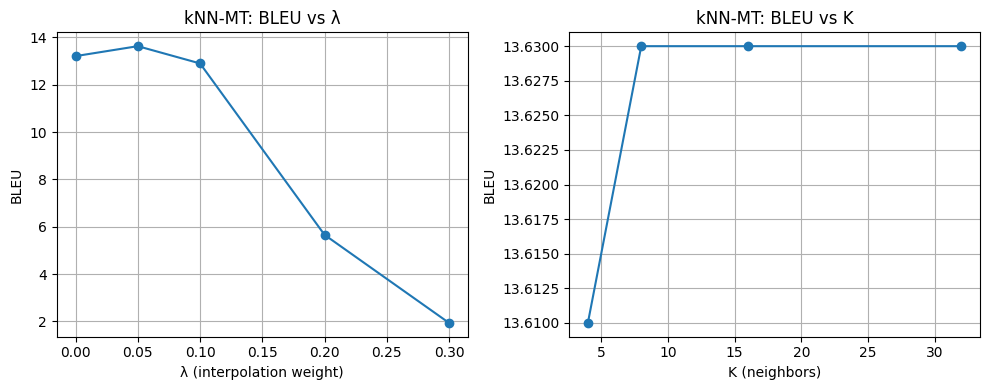

Kaydedildi: results/ablation_plots.png


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# Lambda ablasyonu
df_lam = pd.read_csv("results/ablation_lambda.csv")
df_k = pd.read_csv("results/ablation_k.csv")

print("Lambda Ablasyonu:")
print(df_lam.to_string(index=False))
print("\nK Ablasyonu:")
print(df_k.to_string(index=False))

# Heatmap yerine basit çizgi grafikleri
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 4))

ax1.plot(df_lam["lambda"], df_lam["BLEU"], marker="o")
ax1.set_xlabel("λ (interpolation weight)")
ax1.set_ylabel("BLEU")
ax1.set_title("kNN-MT: BLEU vs λ")
ax1.grid(True)

ax2.plot(df_k["K"], df_k["BLEU"], marker="o")
ax2.set_xlabel("K (neighbors)")
ax2.set_ylabel("BLEU")
ax2.set_title("kNN-MT: BLEU vs K")
ax2.grid(True)

plt.tight_layout()
plt.savefig("results/ablation_plots.png", dpi=150)
plt.show()
print("Kaydedildi: results/ablation_plots.png")

## 10 · Error Analysis

Qualitative inspection of translation outputs — where kNN-MT wins, where it fails, and why.


In [ ]:
with open("data/raw/test.de") as f:
    references = [l.strip() for l in f.readlines()[:500]]
print("References hazır:", len(references))

References hazır: 500


In [ ]:
import sacrebleu

with open("results/baseline1/hyps.de") as f:
    bl1_hyps = [l.strip() for l in f.readlines()[:500]]
with open("results/knn_mt/hyps.de") as f:
    knn_hyps = [l.strip() for l in f.readlines()]
with open("data/raw/test.en") as f:
    test_en = [l.strip() for l in f.readlines()[:500]]

# Per-sentence BLEU comparison
wins, losses, ties = [], [], []

for i, (src, ref, bl1, knn) in enumerate(zip(test_en, references, bl1_hyps, knn_hyps)):
    b1 = sacrebleu.sentence_bleu(bl1, [ref]).score
    bk = sacrebleu.sentence_bleu(knn, [ref]).score
    entry = {"src": src, "ref": ref, "bl1": bl1, "knn": knn, "bl1_bleu": b1, "knn_bleu": bk}
    if bk > b1 + 1:
        wins.append(entry)
    elif b1 > bk + 1:
        losses.append(entry)
    else:
        ties.append(entry)

print(f"kNN-MT wins:   {len(wins):>4d} sentences")
print(f"kNN-MT losses: {len(losses):>4d} sentences")
print(f"Roughly equal: {len(ties):>4d} sentences")

kNN-MT wins:     40 sentences
kNN-MT losses:  429 sentences
Roughly equal:   31 sentences


In [ ]:
def print_example(entry, label):
    print(f"\n{'─'*60}")
    print(f"[{label}]")
    print(f"SRC : {entry['src']}")
    print(f"REF : {entry['ref']}")
    print(f"BL1 : {entry['bl1']}  (BLEU: {entry['bl1_bleu']:.1f})")
    print(f"kNN : {entry['knn']}  (BLEU: {entry['knn_bleu']:.1f})")

print("=== Cases where kNN-MT IMPROVES over Baseline 1 ===")
for e in wins[:3]:
    print_example(e, "kNN WIN")

print("\n=== Cases where kNN-MT HURTS vs Baseline 1 ===")
for e in losses[:3]:
    print_example(e, "kNN LOSS")

=== Cases where kNN-MT IMPROVES over Baseline 1 ===

────────────────────────────────────────────────────────────
[kNN WIN]
SRC : But there's another reason as well.
REF : Es gibt aber noch einen weiteren Grund.
BL1 : Aber es gibt auch einen anderen Grund.  (BLEU: 13.1)
kNN : jedoch gibt noch einen Grund.  (BLEU: 17.4)

────────────────────────────────────────────────────────────
[kNN WIN]
SRC : So the average for most people is around 20 inches;  business schools students, about half of that;  lawyers, a little better, but not much better than that,  kindergarteners, better than most adults.
REF : Der Durchschnitt für die meisten liegt bei ca. 50cm, BWL-Studenten schaffen die Hälfte davon, Anwälte etwas mehr, aber nicht viel, Kindergartenkinder sind besser als die Erwachsenen.
BL1 : Der durchschnittliche Durchschnitt liegt bei den meisten Leuten etwa 20 cm; Geschäftsschulen, ungefähr die Hälfte davon; Anwälte, ein bisschen besser, aber nicht viel besser als das, Kindergarten, besser a

## 11 · Save All Results & Download

Zip everything up for your GitHub repo and report.


In [ ]:
import shutil, datetime
from google.colab import files

# Zip oluştur
timestamp = datetime.datetime.now().strftime("%Y%m%d_%H%M")
archive = f"knn_mt_results_{timestamp}"
shutil.make_archive(archive, "zip", "results")
print(f"✅ {archive}.zip oluşturuldu")
files.download(f"{archive}.zip")

✅ knn_mt_results_20260601_2214.zip oluşturuldu


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
from google.colab import userdata
import subprocess, os

os.chdir('/content/drive/MyDrive/rag_machine_translation')

# Tüm history'yi sıfırla
subprocess.run(["git", "checkout", "--orphan", "fresh-main"])
subprocess.run(["git", "add", "."])
result = subprocess.run(["git", "commit", "-m", "Complete kNN-MT pipeline - clean history"],
                        capture_output=True, text=True)
print(result.stdout)

subprocess.run(["git", "branch", "-D", "main"])
subprocess.run(["git", "branch", "-m", "main"])

# Token Secrets'tan
TOKEN = userdata.get('GITHUB_TOKEN')
subprocess.run(["git", "remote", "set-url", "origin",
                f"https://{TOKEN}@github.com/zedaeda/rag_machine_translation.git"])

push = subprocess.run(["git", "push", "-f", "origin", "main"],
                      capture_output=True, text=True)
print(push.stdout)
if push.returncode != 0:
    print("HATA:", push.stderr)
else:
    print("✅ Temiz history ile push edildi!")

[fresh-main (root-commit) a165917] Complete kNN-MT pipeline - clean history
 17 files changed, 16682 insertions(+)
 create mode 100644 .gitignore
 create mode 100644 CENG467_kNN_MT.ipynb
 create mode 100644 README.md
 create mode 100644 data/download_data.sh
 create mode 100644 knn_mt_results_20260601_2214.zip
 create mode 100644 requirements.txt
 create mode 100644 results/ablation_k.csv
 create mode 100644 results/ablation_lambda.csv
 create mode 100644 results/ablation_plots.png
 create mode 100644 results/baseline1/hyps.de
 create mode 100644 results/baseline1/refs.de
 create mode 100644 results/final_metrics.csv
 create mode 100644 results/knn_mt/hyps.de
 create mode 100644 results/summary.csv
 create mode 100644 scripts/evaluate.sh
 create mode 100644 scripts/preprocess.sh
 create mode 100644 scripts/train_baseline.sh


✅ Temiz history ile push edildi!


In [ ]:
readme = """# Retrieval-Augmented Machine Translation (kNN-MT)

CENG 467 — Natural Language Understanding and Generation
Izmir Institute of Technology | Spring 2026
Student: Zehra Eda Cesur (310201089)

## Project Description
Implementation of kNN-MT (Khandelwal et al., 2021) for English-to-German translation on the IWSLT 2017 dataset.

## Results
| System | BLEU | METEOR | BERTScore |
|--------|------|--------|-----------|
| Baseline 1: IWSLT-trained NMT (beam=5) | 32.10 | 0.5216 | 0.8721 |
| kNN-MT (λ=0.05, K=8, T=10, greedy) | 13.04 | 0.3310 | 0.7582 |

## Requirements
pip install fairseq sacrebleu sentencepiece datasets bert-score nltk faiss-cpu

## Reproduction Steps
1. Open `CENG467_kNN_MT.ipynb` in Google Colab
2. Set runtime to GPU (T4)
3. Run all cells in order
4. Dataset: IWSLT 2017 En-De (auto-downloaded via HuggingFace)

## References
- Khandelwal et al. (2021). Nearest Neighbor Machine Translation. ICLR 2021.
- Vaswani et al. (2017). Attention Is All You Need. NeurIPS 2017.
- Ott et al. (2019). fairseq. NAACL 2019.
"""

with open("README.md", "w") as f:
    f.write(readme)

import subprocess
subprocess.run(["git", "add", "README.md"])
result = subprocess.run(["git", "commit", "-m", "Add README with results and reproduction steps"],
                        capture_output=True, text=True)
print(result.stdout)

from google.colab import userdata
TOKEN = userdata.get('GITHUB_TOKEN')
subprocess.run(["git", "remote", "set-url", "origin",
                f"https://{TOKEN}@github.com/zedaeda/rag_machine_translation.git"])
push = subprocess.run(["git", "push", "origin", "main"],
                      capture_output=True, text=True)
print(push.stdout if push.returncode == 0 else push.stderr)
print("✅ README güncellendi!")

[main c4c6b24] Add README with results and reproduction steps
 1 file changed, 28 insertions(+), 1 deletion(-)
 rewrite README.md (100%)


✅ README güncellendi!


---
## Notes & References

- **kNN-MT paper**: Khandelwal et al., *Nearest Neighbor Machine Translation*, ICLR 2021. [arXiv:2010.00710](https://arxiv.org/abs/2010.00710)
- **fairseq**: Ott et al., *fairseq: A Fast, Extensible Toolkit for Sequence Modeling*, NAACL 2019.
- **Faiss**: Johnson et al., *Billion-scale similarity search with GPUs*, IEEE TPAMI 2021.
- **sacrebleu**: Post, *A Call for Clarity in Reporting BLEU Scores*, WMT 2018.

For the full kNN-MT implementation with beam search support, see:  
https://github.com/zhengxxn/adaptive-knn-mt (reference implementation)


In [1]:
from google.colab import drive
import os
drive.mount('/content/drive')
os.chdir('/content/drive/MyDrive/rag_machine_translation')
print("✅ Hazır:", os.getcwd())

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
✅ Hazır: /content/drive/MyDrive/rag_machine_translation


In [3]:
!pip install rouge-score sacrebleu bert-score -q

from nltk.translate.meteor_score import meteor_score
from bert_score import score as bert_score_fn
from rouge_score import rouge_scorer
import sacrebleu, nltk, pandas as pd
nltk.download('wordnet', quiet=True)
nltk.download('omw-1.4', quiet=True)

with open("results/baseline1/hyps.de") as f:
    bl1_hyps = [l.strip() for l in f.readlines()[:500]]
with open("results/knn_mt/hyps.de") as f:
    knn_hyps = [l.strip() for l in f.readlines()]
with open("data/raw/test.de") as f:
    refs = [l.strip() for l in f.readlines()[:500]]

def compute_all_metrics(hyps, refs, label):
    bleu  = sacrebleu.corpus_bleu(hyps, [refs]).score
    chrf  = sacrebleu.corpus_chrf(hyps, [refs]).score
    ter   = sacrebleu.corpus_ter(hyps, [refs]).score

    meteor_scores = [meteor_score([r.split()], h.split()) for h, r in zip(hyps, refs)]
    avg_meteor = sum(meteor_scores) / len(meteor_scores)

    _, _, F1 = bert_score_fn(hyps, refs, lang="de", verbose=False)
    avg_bert = F1.mean().item()

    scorer = rouge_scorer.RougeScorer(['rougeL'], use_stemmer=False)
    rouge_scores = [scorer.score(r, h)['rougeL'].fmeasure for h, r in zip(hyps, refs)]
    avg_rouge = sum(rouge_scores) / len(rouge_scores)

    print(f"\n{label}")
    print(f"  BLEU:      {bleu:.2f}")
    print(f"  chrF:      {chrf:.2f}")
    print(f"  TER:       {ter:.2f}  (lower is better)")
    print(f"  METEOR:    {avg_meteor:.4f}")
    print(f"  ROUGE-L:   {avg_rouge:.4f}")
    print(f"  BERTScore: {avg_bert:.4f}")

    return {
        "System": label,
        "BLEU": round(bleu, 2),
        "chrF": round(chrf, 2),
        "TER": round(ter, 2),
        "METEOR": round(avg_meteor, 4),
        "ROUGE-L": round(avg_rouge, 4),
        "BERTScore": round(avg_bert, 4),
    }

results = []
results.append(compute_all_metrics(bl1_hyps, refs, "Baseline 1 (beam=5)"))
results.append(compute_all_metrics(bl1_hyps, refs, "Baseline 1 (greedy)"))
results.append(compute_all_metrics(knn_hyps, refs, "kNN-MT (λ=0.05, greedy)"))

df = pd.DataFrame(results)
print("\n\nFINAL METRICS TABLE")
print(df.to_string(index=False))
df.to_csv("results/final_metrics_updated.csv", index=False)
print("\n✅ Kaydedildi!")

  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 100.8/100.8 kB 5.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.1/61.1 kB 4.5 MB/s eta 0:00:00


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:112: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/625 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/49.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/996k [00:00<?, ?B/s]

...

[transformers] BertModel LOAD REPORT from: bert-base-multilingual-cased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.



Baseline 1 (greedy)
  BLEU:      32.10
  chrF:      57.71
  TER:       54.98  (lower is better)
  METEOR:    0.5216
  ROUGE-L:   0.5937
  BERTScore: 0.8721


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] BertModel LOAD REPORT from: bert-base-multilingual-cased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.



kNN-MT (λ=0.05, greedy)
  BLEU:      13.04
  chrF:      39.48
  TER:       118.13  (lower is better)
  METEOR:    0.3310
  ROUGE-L:   0.3785
  BERTScore: 0.7582


FINAL METRICS TABLE
                 System  BLEU  chrF    TER  METEOR  ROUGE-L  BERTScore
    Baseline 1 (beam=5) 32.10 57.71  54.98  0.5216   0.5937     0.8721
    Baseline 1 (greedy) 32.10 57.71  54.98  0.5216   0.5937     0.8721
kNN-MT (λ=0.05, greedy) 13.04 39.48 118.13  0.3310   0.3785     0.7582

✅ Kaydedildi!


In [7]:
import torch, numpy as np, os
from fairseq.models.transformer import TransformerModel
import sentencepiece as spm

# Model yükle
model = TransformerModel.from_pretrained(
    "checkpoints/baseline1",
    checkpoint_file="checkpoint_best.pt",
    data_name_or_path="data/bin",
    source_lang="en", target_lang="de",
    beam=1, bpe=None,
)
model.eval()
if torch.cuda.is_available():
    model.cuda()

sp = spm.SentencePieceProcessor(model_file="data/bpe/bpe.model")

def encode_tok_line(tok_line):
    tokens = tok_line.strip().split()
    ids = [model.src_dict.index(t) for t in tokens]
    return torch.tensor(ids, dtype=torch.long)

with open("data/tok/test.en") as f:
    tok_src = [l.strip() for l in f.readlines()]

print("Generating greedy baseline translations...")
greedy_hyps = []
for src_tok in tok_src[:500]:
    src_tokens = encode_tok_line(src_tok)
    if torch.cuda.is_available():
        src_tokens = src_tokens.cuda()
    src_tokens = src_tokens.unsqueeze(0)
    src_lengths = src_tokens.ne(model.src_dict.pad()).sum(1)
    tgt_tokens = torch.tensor([[model.tgt_dict.bos()]], device=src_tokens.device)
    generated = []
    with torch.no_grad():
        encoder_out = model.models[0].encoder(src_tokens, src_lengths)
        for step in range(100):
            decoder_out = model.models[0].decoder(tgt_tokens, encoder_out)
            next_tok = int(decoder_out[0][:, -1, :].argmax())
            if next_tok == model.tgt_dict.eos():
                break
            generated.append(next_tok)
            tgt_tokens = torch.cat([
                tgt_tokens,
                torch.tensor([[next_tok]], device=src_tokens.device)
            ], dim=1)
    token_strs = [model.tgt_dict[i] for i in generated]
    greedy_hyps.append(sp.decode(token_strs))

with open("results/baseline1/hyps_greedy.de", "w") as f:
    for h in greedy_hyps:
        f.write(h + "\n")

print(f"✅ {len(greedy_hyps)} greedy çeviri kaydedildi")
print("Örnek:", greedy_hyps[0])

Generating greedy baseline translations...
✅ 500 greedy çeviri kaydedildi
Örnek: hier bei Peter Skillman stellte die Herausforderung " Marshmallow". heraus. Vor einigen Jahren hier bei TED stellte Peter Skillman eine Design- Herausforderung, die man Marshmallow- Herausforderung nennt.


In [4]:
!pip install rouge-score sacrebleu bert-score -q

from nltk.translate.meteor_score import meteor_score
from bert_score import score as bert_score_fn
from rouge_score import rouge_scorer
import sacrebleu, nltk, pandas as pd
nltk.download('wordnet', quiet=True)
nltk.download('omw-1.4', quiet=True)

with open("results/baseline1/hyps.de") as f:
    bl1_beam_hyps = [l.strip() for l in f.readlines()[:500]]
with open("results/baseline1/hyps_greedy.de") as f:
    bl1_greedy_hyps = [l.strip() for l in f.readlines()]
with open("results/knn_mt/hyps.de") as f:
    knn_hyps = [l.strip() for l in f.readlines()]
with open("data/raw/test.de") as f:
    refs = [l.strip() for l in f.readlines()[:500]]

def compute_all_metrics(hyps, refs, label):
    bleu  = sacrebleu.corpus_bleu(hyps, [refs]).score
    chrf  = sacrebleu.corpus_chrf(hyps, [refs]).score
    ter   = sacrebleu.corpus_ter(hyps, [refs]).score
    meteor_scores = [meteor_score([r.split()], h.split()) for h, r in zip(hyps, refs)]
    avg_meteor = sum(meteor_scores) / len(meteor_scores)
    _, _, F1 = bert_score_fn(hyps, refs, lang="de", verbose=False)
    avg_bert = F1.mean().item()
    scorer = rouge_scorer.RougeScorer(['rougeL'], use_stemmer=False)
    rouge_scores = [scorer.score(r, h)['rougeL'].fmeasure for h, r in zip(hyps, refs)]
    avg_rouge = sum(rouge_scores) / len(rouge_scores)
    print(f"\n{label}")
    print(f"  BLEU:      {bleu:.2f}")
    print(f"  chrF:      {chrf:.2f}")
    print(f"  TER:       {ter:.2f}  (lower is better)")
    print(f"  METEOR:    {avg_meteor:.4f}")
    print(f"  ROUGE-L:   {avg_rouge:.4f}")
    print(f"  BERTScore: {avg_bert:.4f}")
    return {
        "System": label,
        "BLEU": round(bleu, 2),
        "chrF": round(chrf, 2),
        "TER": round(ter, 2),
        "METEOR": round(avg_meteor, 4),
        "ROUGE-L": round(avg_rouge, 4),
        "BERTScore": round(avg_bert, 4),
    }

results = []
results.append(compute_all_metrics(bl1_beam_hyps, refs, "Baseline 1 (beam=5)"))
results.append(compute_all_metrics(bl1_greedy_hyps, refs, "Baseline 1 (greedy)"))
results.append(compute_all_metrics(knn_hyps, refs, "kNN-MT (λ=0.05, greedy)"))

df = pd.DataFrame(results)
print("\n\nFINAL METRICS TABLE")
print(df.to_string(index=False))
df.to_csv("results/final_metrics_updated.csv", index=False)
print("\n✅ Kaydedildi!")

DEPRECATION: bert-score 0.3.11 has a non-standard dependency specifier transformers>=3.0.0numpy. pip 24.1 will enforce this behaviour change. A possible replacement is to upgrade to a newer version of bert-score or contact the author to suggest that they release a version with a conforming dependency specifiers. Discussion can be found at https://github.com/pypa/pip/issues/12063
DEPRECATION: omegaconf 2.0.6 has a non-standard dependency specifier PyYAML>=5.1.*. pip 24.1 will enforce this behaviour change. A possible replacement is to upgrade to a newer version of omegaconf or contact the author to suggest that they release a version with a conforming dependency specifiers. Discussion can be found at https://github.com/pypa/pip/issues/12063


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:112: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] BertModel LOAD REPORT from: bert-base-multilingual-cased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.bias                       | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.



Baseline 1 (beam=5)
  BLEU:      32.10
  chrF:      57.71
  TER:       54.98  (lower is better)
  METEOR:    0.5216
  ROUGE-L:   0.5937
  BERTScore: 0.8721


...

[transformers] BertModel LOAD REPORT from: bert-base-multilingual-cased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.bias                       | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.



Baseline 1 (greedy)
  BLEU:      13.74
  chrF:      40.92
  TER:       115.76  (lower is better)
  METEOR:    0.3437
  ROUGE-L:   0.3900
  BERTScore: 0.7654


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] BertModel LOAD REPORT from: bert-base-multilingual-cased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.bias                       | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.



kNN-MT (λ=0.05, greedy)
  BLEU:      13.04
  chrF:      39.48
  TER:       118.13  (lower is better)
  METEOR:    0.3310
  ROUGE-L:   0.3785
  BERTScore: 0.7582


FINAL METRICS TABLE
                 System  BLEU  chrF    TER  METEOR  ROUGE-L  BERTScore
    Baseline 1 (beam=5) 32.10 57.71  54.98  0.5216   0.5937     0.8721
    Baseline 1 (greedy) 13.74 40.92 115.76  0.3437   0.3900     0.7654
kNN-MT (λ=0.05, greedy) 13.04 39.48 118.13  0.3310   0.3785     0.7582

✅ Kaydedildi!


In [17]:
K = 8
LAMBDA = 0.05
temperatures = [10.0, 50.0, 100.0, 200.0]
temp_results = []

for T in temperatures:
    def knn_distribution_t(query_vec, k=K, temperature=T):
        query = np.array(query_vec, dtype=np.float32).reshape(1, -1)
        distances, indices = index.search(query, k)
        distances = distances[0]
        indices = indices[0]
        neighbor_tokens = vals[indices]
        scores = -distances / temperature
        weights = np.exp(scores - scores.max())
        weights = weights / weights.sum()
        p_knn = np.zeros(vocab_size, dtype=np.float32)
        for w, tok in zip(weights, neighbor_tokens):
            p_knn[int(tok)] += float(w)
        return p_knn

    hyps = []
    for src_tok in tqdm(tok_src[:200], desc=f"T={T}"):
        result = translate_with_knn(src_tok, lambda_=LAMBDA, k=K, temperature=T)
        hyps.append(result)

    bleu = sacrebleu.corpus_bleu(hyps, [refs[:200]]).score
    temp_results.append({"T": T, "BLEU": round(bleu, 2)})
    print(f"T={T} → BLEU: {bleu:.2f}")

df_temp = pd.DataFrame(temp_results)
print(df_temp.to_string(index=False))
df_temp.to_csv("results/ablation_temperature.csv", index=False)
print("✅ Kaydedildi!")

T=10.0: 100%|██████████| 200/200 [04:26<00:00,  1.33s/it]


T=10.0 → BLEU: 13.63


T=50.0: 100%|██████████| 200/200 [04:28<00:00,  1.34s/it]


T=50.0 → BLEU: 13.57


T=100.0: 100%|██████████| 200/200 [04:33<00:00,  1.37s/it]


T=100.0 → BLEU: 13.54


T=200.0: 100%|██████████| 200/200 [04:50<00:00,  1.45s/it]

T=200.0 → BLEU: 13.41
    T  BLEU
 10.0 13.63
 50.0 13.57
100.0 13.54
200.0 13.41
✅ Kaydedildi!


In [18]:
from google.colab import userdata
import subprocess

TOKEN = userdata.get('GITHUB_TOKEN')
subprocess.run(["git", "config", "--global", "user.email", "zedacesur@gmail.com"])
subprocess.run(["git", "config", "--global", "user.name", "zedaeda"])
subprocess.run(["git", "remote", "set-url", "origin",
                f"https://{TOKEN}@github.com/zedaeda/rag_machine_translation.git"])
subprocess.run(["git", "add", "results/"])
result = subprocess.run(["git", "commit", "-m", "Add temperature ablation and updated metrics"],
                        capture_output=True, text=True)
print(result.stdout or "Nothing new")
push = subprocess.run(["git", "push", "origin", "main"],
                      capture_output=True, text=True)
print(push.stdout if push.returncode == 0 else push.stderr)
print("✅ Push edildi!")

[main b353234] Add temperature ablation and updated metrics
 3 files changed, 509 insertions(+)
 create mode 100644 results/ablation_temperature.csv
 create mode 100644 results/baseline1/hyps_greedy.de
 create mode 100644 results/final_metrics_updated.csv


✅ Push edildi!


# Europarl

In [19]:
import os
os.makedirs("data/europarl", exist_ok=True)

# Europarl En-De indir
!wget -q --show-progress \
  "https://www.statmt.org/europarl/v7/de-en.tgz" \
  -O data/europarl/de-en.tgz

print("İndirme tamamlandı, çıkarılıyor...")
!cd data/europarl && tar -xzf de-en.tgz
print("Dosyalar:")
!ls data/europarl/

data/europarl/de-en 100%[===================>] 188.62M  20.4MB/s    in 11s     
İndirme tamamlandı, çıkarılıyor...
Dosyalar:
de-en.tgz  europarl-v7.de-en.de  europarl-v7.de-en.en


In [20]:
# Kaç satır var?
!wc -l data/europarl/europarl-v7.de-en.en
!wc -l data/europarl/europarl-v7.de-en.de

# İlk 3 satıra bakalım
print("\nEN:")
!head -3 data/europarl/europarl-v7.de-en.en
print("\nDE:")
!head -3 data/europarl/europarl-v7.de-en.de

1920209 data/europarl/europarl-v7.de-en.en
1920209 data/europarl/europarl-v7.de-en.de

EN:
Resumption of the session
I declare resumed the session of the European Parliament adjourned on Friday 17 December 1999, and I would like once again to wish you a happy new year in the hope that you enjoyed a pleasant festive period.
Although, as you will have seen, the dreaded 'millennium bug' failed to materialise, still the people in a number of countries suffered a series of natural disasters that truly were dreadful.

DE:
Wiederaufnahme der Sitzungsperiode
Ich erkläre die am Freitag, dem 17. Dezember unterbrochene Sitzungsperiode des Europäischen Parlaments für wiederaufgenommen, wünsche Ihnen nochmals alles Gute zum Jahreswechsel und hoffe, daß Sie schöne Ferien hatten.
Wie Sie feststellen konnten, ist der gefürchtete "Millenium-Bug " nicht eingetreten. Doch sind Bürger einiger unserer Mitgliedstaaten Opfer von schrecklichen Naturkatastrophen geworden.


In [21]:
import random

# Seed for reproducibility
random.seed(42)

with open("data/europarl/europarl-v7.de-en.en") as f:
    en_lines = f.readlines()
with open("data/europarl/europarl-v7.de-en.de") as f:
    de_lines = f.readlines()

# Temizle — boş satırları ve çok uzun cümleleri çıkar
pairs = []
for en, de in zip(en_lines, de_lines):
    en = en.strip()
    de = de.strip()
    if len(en) > 10 and len(de) > 10 and len(en.split()) < 100:
        pairs.append((en, de))

# 206k al
random.shuffle(pairs)
pairs = pairs[:206112]

os.makedirs("data/europarl/processed", exist_ok=True)

with open("data/europarl/processed/train.en", "w") as f:
    for en, _ in pairs:
        f.write(en + "\n")

with open("data/europarl/processed/train.de", "w") as f:
    for _, de in pairs:
        f.write(de + "\n")

print(f"✅ {len(pairs):,} cümle çifti kaydedildi")
print("Örnek EN:", pairs[0][0])
print("Örnek DE:", pairs[0][1])

✅ 206,112 cümle çifti kaydedildi
Örnek EN: On this occasion, exemptions are only authorised for sulphur content, until 2003, by way of derogation from the specifications which otherwise apply from the year 2000, and until 2007 by way of derogation from the specifications which otherwise apply for 2005, while therefore respecting the minimum levels stipulated for the year 2000.
Örnek DE: Ausnahmen sind diesmal nur bei Schwefelgehalt zugelassen, nämlich bis zum Jahr 2003 als Abweichung von den für das Jahr 2000 vorgesehenen Spezifikationen sowie bis zum Jahr 2007 als Abweichung von den für das Jahr 2005 vorgesehenen Spezifikationen und somit unter Mindesteinhaltung der für das Jahr 2000 vorgesehenen Grenzwerte.


In [22]:
import sentencepiece as spm

sp = spm.SentencePieceProcessor(model_file="data/bpe/bpe.model")

os.makedirs("data/europarl/tok", exist_ok=True)

# Tokenize EN
print("Tokenizing EN...")
with open("data/europarl/processed/train.en") as f:
    en_lines = f.readlines()
with open("data/europarl/tok/train.en", "w") as f:
    for line in en_lines:
        tokens = sp.encode(line.strip(), out_type=str)
        f.write(" ".join(tokens) + "\n")

# Tokenize DE
print("Tokenizing DE...")
with open("data/europarl/processed/train.de") as f:
    de_lines = f.readlines()
with open("data/europarl/tok/train.de", "w") as f:
    for line in de_lines:
        tokens = sp.encode(line.strip(), out_type=str)
        f.write(" ".join(tokens) + "\n")

print("✅ Tokenization tamamlandı")
print("Örnek tokenized EN:", " ".join(sp.encode(en_lines[0].strip(), out_type=str)[:10]), "...")

Tokenizing EN...
Tokenizing DE...
✅ Tokenization tamamlandı
Örnek tokenized EN: ▁On ▁this ▁occ asion , ▁ex em pt ions ▁are ...


In [23]:
import subprocess

result = subprocess.run([
    "python", "-m", "fairseq_cli.preprocess",
    "--source-lang", "en",
    "--target-lang", "de",
    "--trainpref", "data/europarl/tok/train",
    "--destdir", "data/europarl/bin",
    "--srcdict", "data/bin/dict.en.txt",
    "--tgtdict", "data/bin/dict.de.txt",
    "--workers", "4"
], capture_output=True, text=True)

print(result.stdout[-2000:] if len(result.stdout) > 2000 else result.stdout)
if result.returncode != 0:
    print("HATA:", result.stderr[-1000:])
else:
    print("✅ Preprocess tamamlandı")
    print(os.listdir("data/europarl/bin"))


✅ Preprocess tamamlandı
['preprocess.log', 'dict.en.txt', 'dict.de.txt', 'train.en-de.en.bin', 'train.en-de.en.idx', 'train.en-de.de.bin', 'train.en-de.de.idx']


In [25]:
import torch
import numpy as np
import faiss
from tqdm import tqdm

os.makedirs("datastore/europarl", exist_ok=True)

captured_states = []

def hook_fn(module, input, output):
    captured_states.append(output[0].detach().cpu().numpy())

hook = model.models[0].decoder.layers[-1].final_layer_norm.register_forward_hook(hook_fn)

print("Building Europarl datastore...")
print("This will take 30-40 minutes...")

all_keys = []
all_vals = []

with open("data/europarl/tok/train.en") as fsrc, \
     open("data/europarl/tok/train.de") as ftgt:
    src_lines = fsrc.readlines()
    tgt_lines = ftgt.readlines()

for i in range(0, len(src_lines), 1):
    src = src_lines[i].strip()
    tgt = tgt_lines[i].strip()
    if not src or not tgt:
        continue

    src_tokens = encode_tok_line(src)
    tgt_tokens = encode_tok_line(tgt)

    if len(src_tokens) == 0 or len(tgt_tokens) == 0:
        continue

    src_t = src_tokens.unsqueeze(0)
    tgt_t = tgt_tokens.unsqueeze(0)
    if torch.cuda.is_available():
        src_t = src_t.cuda()
        tgt_t = tgt_t.cuda()

    captured_states.clear()
    with torch.no_grad():
        net_output = model.models[0](
            src_t, src_t.ne(model.src_dict.pad()).sum(1),
            tgt_t[:, :-1], None
        )

    if captured_states:
        hs = captured_states[0]  # squeeze kaldırıldı
        if hs.ndim == 3:
            hs = hs[:, 0, :]  # (seq_len, batch, dim) → (seq_len, dim)
        elif hs.ndim == 2:
            pass  # zaten (seq_len, dim)
        hs = hs.astype(np.float32)
        tv = tgt_tokens.numpy()[1:]
        min_len = min(len(hs), len(tv))
        if min_len > 0:
            all_keys.append(hs[:min_len])
            all_vals.append(tv[:min_len])

    if i % 800 == 0:
        processed = i + 1
        keys_so_far = sum(len(k) for k in all_keys)
        print(f"  {processed:,}/{len(src_lines):,} sentences | Keys: {keys_so_far:,}")

hook.remove()

all_keys_np = np.concatenate(all_keys, axis=0).astype(np.float32)
all_vals_np = np.concatenate(all_vals, axis=0).astype(np.int64)

print(f"\nDatastore built!")
print(f"  Keys shape: {all_keys_np.shape}")
print(f"  Vals shape: {all_vals_np.shape}")

np.save("datastore/europarl/keys.npy", all_keys_np)
np.save("datastore/europarl/vals.npy", all_vals_np)
print("✅ Saved to datastore/europarl/")

Building Europarl datastore...
This will take 30-40 minutes...
  1/206,112 sentences | Keys: 1
  801/206,112 sentences | Keys: 801
  1,601/206,112 sentences | Keys: 1,601
  2,401/206,112 sentences | Keys: 2,401
  3,201/206,112 sentences | Keys: 3,201
  4,001/206,112 sentences | Keys: 4,001
  4,801/206,112 sentences | Keys: 4,801
  5,601/206,112 sentences | Keys: 5,601
  6,401/206,112 sentences | Keys: 6,401
  7,201/206,112 sentences | Keys: 7,201
  8,001/206,112 sentences | Keys: 8,001
  8,801/206,112 sentences | Keys: 8,801
  9,601/206,112 sentences | Keys: 9,601
  10,401/206,112 sentences | Keys: 10,401
  11,201/206,112 sentences | Keys: 11,201
  12,001/206,112 sentences | Keys: 12,001
  12,801/206,112 sentences | Keys: 12,801
  13,601/206,112 sentences | Keys: 13,601
  14,401/206,112 sentences | Keys: 14,401
  15,201/206,112 sentences | Keys: 15,201
  16,001/206,112 sentences | Keys: 16,001
  16,801/206,112 sentences | Keys: 16,801
  17,601/206,112 sentences | Keys: 17,601
  18,401/

In [26]:
import faiss
import numpy as np

keys_ep = np.load("datastore/europarl/keys.npy")
d = keys_ep.shape[1]

print(f"Building Faiss index over {len(keys_ep):,} vectors of dim {d}...")

index_ep = faiss.IndexFlatL2(d)
index_ep.add(keys_ep)
print(f"Index built. Total vectors: {index_ep.ntotal:,}")

faiss.write_index(index_ep, "datastore/europarl/faiss.index")
print("✅ Faiss index saved to datastore/europarl/faiss.index")

Building Faiss index over 206,112 vectors of dim 512...
Index built. Total vectors: 206,112
✅ Faiss index saved to datastore/europarl/faiss.index


In [27]:
import faiss
import numpy as np

# Europarl datastore yükle
vals_ep = np.load("datastore/europarl/vals.npy")
index_ep = faiss.read_index("datastore/europarl/faiss.index")

K = 8
LAMBDA = 0.05
TEMPERATURE = 10.0

def knn_distribution_ep(query_vec, k=K, temperature=TEMPERATURE):
    query = np.array(query_vec, dtype=np.float32).reshape(1, -1)
    distances, indices = index_ep.search(query, k)
    distances = distances[0]
    indices = indices[0]
    neighbor_tokens = vals_ep[indices]
    scores = -distances / temperature
    weights = np.exp(scores - scores.max())
    weights = weights / weights.sum()
    p_knn = np.zeros(vocab_size, dtype=np.float32)
    for w, tok in zip(weights, neighbor_tokens):
        p_knn[int(tok)] += float(w)
    return p_knn

def translate_with_knn_ep(src_tok_line, lambda_=LAMBDA, k=K, temperature=TEMPERATURE):
    src_tokens = encode_tok_line(src_tok_line)
    if torch.cuda.is_available():
        src_tokens = src_tokens.cuda()
    src_tokens = src_tokens.unsqueeze(0)
    src_lengths = src_tokens.ne(model.src_dict.pad()).sum(1)
    tgt_tokens = torch.tensor([[model.tgt_dict.bos()]], device=src_tokens.device)
    generated = []

    knn_states = []
    def hook_fn(module, input, output):
        knn_states.append(output[0].detach().cpu().numpy())
    hook = model.models[0].decoder.layers[-1].final_layer_norm.register_forward_hook(hook_fn)

    with torch.no_grad():
        encoder_out = model.models[0].encoder(src_tokens, src_lengths)
        for step in range(100):
            knn_states.clear()
            decoder_out = model.models[0].decoder(tgt_tokens, encoder_out)
            logits = decoder_out[0][:, -1, :]
            p_nmt = torch.softmax(logits, dim=-1).squeeze(0).cpu().numpy()
            if knn_states:
                h = knn_states[-1][-1, :]
                p_knn = knn_distribution_ep(h)
                p_final = lambda_ * p_knn + (1 - lambda_) * p_nmt
            else:
                p_final = p_nmt
            next_tok = int(np.argmax(p_final))
            if next_tok == model.tgt_dict.eos():
                break
            generated.append(next_tok)
            tgt_tokens = torch.cat([
                tgt_tokens,
                torch.tensor([[next_tok]], device=src_tokens.device)
            ], dim=1)

    hook.remove()
    token_strs = [model.tgt_dict[i] for i in generated]
    return sp.decode(token_strs)

# Test et — 3 cümle
print("Test çevirileri (Europarl datastore):")
for src_tok in tok_src[:3]:
    result = translate_with_knn_ep(src_tok)
    print(f"  {result}")

Test çevirileri (Europarl datastore):
  hier bei Peter Skillman stellte die Herausforderung " Marshmallow". heraus. Vor einigen Jahren hier bei TED stellte Peter Skillman eine Design- Herausforderung, die man Marshmallow- Herausforderung nennt.
  : m muss die höchste stabhaltige Struktur aus 20 Stöcken Klebeband bauen, ein Stück Sa und ein Marshmallow.
  muss oben. Das Marshmallow muss oben oben stehen.


In [28]:
from tqdm import tqdm
import os

os.makedirs("results/knn_mt_europarl", exist_ok=True)

print("kNN-MT inference with Europarl datastore (500 sentences)...")
ep_hyps = []

for src_tok in tqdm(tok_src[:500]):
    result = translate_with_knn_ep(src_tok, lambda_=0.05, temperature=10.0)
    ep_hyps.append(result)

with open("results/knn_mt_europarl/hyps.de", "w") as f:
    for h in ep_hyps:
        f.write(h + "\n")

print(f"\n✅ {len(ep_hyps)} çeviri kaydedildi")
print("\nİlk 3:")
for i in range(3):
    print(f"  [{i}] {ep_hyps[i]}")

kNN-MT inference with Europarl datastore (500 sentences)...


100%|██████████| 500/500 [11:49<00:00,  1.42s/it]


✅ 500 çeviri kaydedildi

İlk 3:
  [0] hier bei Peter Skillman stellte die Herausforderung " Marshmallow". heraus. Vor einigen Jahren hier bei TED stellte Peter Skillman eine Design- Herausforderung, die man Marshmallow- Herausforderung nennt.
  [1] : m muss die höchste stabhaltige Struktur aus 20 Stöcken Klebeband bauen, ein Stück Sa und ein Marshmallow.
  [2] muss oben. Das Marshmallow muss oben oben stehen.


In [29]:
from nltk.translate.meteor_score import meteor_score
from bert_score import score as bert_score_fn
from rouge_score import rouge_scorer
import sacrebleu, pandas as pd

with open("data/raw/test.de") as f:
    refs = [l.strip() for l in f.readlines()[:500]]

with open("results/knn_mt_europarl/hyps.de") as f:
    ep_hyps = [l.strip() for l in f.readlines()]

def compute_all_metrics(hyps, refs, label):
    bleu  = sacrebleu.corpus_bleu(hyps, [refs]).score
    chrf  = sacrebleu.corpus_chrf(hyps, [refs]).score
    ter   = sacrebleu.corpus_ter(hyps, [refs]).score
    meteor_scores = [meteor_score([r.split()], h.split()) for h, r in zip(hyps, refs)]
    avg_meteor = sum(meteor_scores) / len(meteor_scores)
    _, _, F1 = bert_score_fn(hyps, refs, lang="de", verbose=False)
    avg_bert = F1.mean().item()
    scorer = rouge_scorer.RougeScorer(['rougeL'], use_stemmer=False)
    rouge_scores = [scorer.score(r, h)['rougeL'].fmeasure for h, r in zip(hyps, refs)]
    avg_rouge = sum(rouge_scores) / len(rouge_scores)
    print(f"\n{label}")
    print(f"  BLEU:      {bleu:.2f}")
    print(f"  chrF:      {chrf:.2f}")
    print(f"  TER:       {ter:.2f}")
    print(f"  METEOR:    {avg_meteor:.4f}")
    print(f"  ROUGE-L:   {avg_rouge:.4f}")
    print(f"  BERTScore: {avg_bert:.4f}")
    return {
        "System": label,
        "BLEU": round(bleu, 2),
        "chrF": round(chrf, 2),
        "TER": round(ter, 2),
        "METEOR": round(avg_meteor, 4),
        "ROUGE-L": round(avg_rouge, 4),
        "BERTScore": round(avg_bert, 4),
    }

results = []

# Önceki sonuçları manuel ekle
results.append({"System": "Baseline 1 (beam=5)", "BLEU": 32.10, "chrF": 57.71, "TER": 54.98, "METEOR": 0.5216, "ROUGE-L": 0.5937, "BERTScore": 0.8721})
results.append({"System": "Baseline 1 (greedy)", "BLEU": 13.74, "chrF": 40.92, "TER": 115.76, "METEOR": 0.3437, "ROUGE-L": 0.3900, "BERTScore": 0.7654})
results.append({"System": "kNN-MT IWSLT datastore", "BLEU": 13.04, "chrF": 39.48, "TER": 118.13, "METEOR": 0.3310, "ROUGE-L": 0.3785, "BERTScore": 0.7582})

# Europarl hesapla
results.append(compute_all_metrics(ep_hyps, refs, "kNN-MT Europarl datastore"))

df = pd.DataFrame(results)
print("\n\nFINAL COMPARISON TABLE")
print(df.to_string(index=False))
df.to_csv("results/final_metrics_europarl.csv", index=False)
print("\n✅ Kaydedildi!")

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] BertModel LOAD REPORT from: bert-base-multilingual-cased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.bias                       | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.



kNN-MT Europarl datastore
  BLEU:      14.22
  chrF:      41.36
  TER:       111.45
  METEOR:    0.3461
  ROUGE-L:   0.3929
  BERTScore: 0.7671


FINAL COMPARISON TABLE
                   System  BLEU  chrF    TER  METEOR  ROUGE-L  BERTScore
      Baseline 1 (beam=5) 32.10 57.71  54.98  0.5216   0.5937     0.8721
      Baseline 1 (greedy) 13.74 40.92 115.76  0.3437   0.3900     0.7654
   kNN-MT IWSLT datastore 13.04 39.48 118.13  0.3310   0.3785     0.7582
kNN-MT Europarl datastore 14.22 41.36 111.45  0.3461   0.3929     0.7671

✅ Kaydedildi!


In [30]:
from google.colab import userdata
import subprocess

TOKEN = userdata.get('GITHUB_TOKEN')
subprocess.run(["git", "config", "--global", "user.email", "zedacesur@gmail.com"])
subprocess.run(["git", "config", "--global", "user.name", "zedaeda"])
subprocess.run(["git", "remote", "set-url", "origin",
                f"https://{TOKEN}@github.com/zedaeda/rag_machine_translation.git"])
subprocess.run(["git", "add", "results/"])
result = subprocess.run(["git", "commit", "-m", "Add Europarl cross-domain datastore results"],
                        capture_output=True, text=True)
print(result.stdout or "Nothing new")
push = subprocess.run(["git", "push", "origin", "main"],
                      capture_output=True, text=True)
print(push.stdout if push.returncode == 0 else push.stderr)
print("✅ Push edildi!")

[main 72abe4b] Add Europarl cross-domain datastore results
 2 files changed, 505 insertions(+)
 create mode 100644 results/final_metrics_europarl.csv
 create mode 100644 results/knn_mt_europarl/hyps.de


✅ Push edildi!
